# FinScore v2.0.2 — PUDIM auditável

## Correção controlada, alertas de viés material e score provisório

Esta versão mantém a arquitetura econômico-financeira da v2.0.1 e acrescenta
uma camada de correção integralmente auditável.

Princípios:

1. o valor reportado nunca é sobrescrito;
2. correções são aplicadas somente na cópia analítica;
3. toda mudança recebe identificador, regra, valor original, valor utilizado,
   confiança, materialidade, impacto provável e necessidade de confirmação;
4. detalhamentos incompatíveis com subtotais são colocados em quarentena, não
   redistribuídos arbitrariamente;
5. valores capazes de enviesar materialmente o score são destacados em aba
   própria;
6. correções automáticas materiais produzem apenas **score provisório** até
   confirmação documental;
7. inconsistências não corrigíveis continuam bloqueando o cálculo.

> O FinScore mede capacidade econômico-financeira relativa. Não estima
> probabilidade de default e não substitui análise cadastral, garantias,
> risco setorial, governança ou julgamento do analista.


## 0. Como usar

1. Informe a planilha em `FINSCORE_PLANILHA` ou edite `CAMINHO_PLANILHA`.
2. Revise a lista `CORRECOES_MANUAIS`; qualquer ajuste manual deve ter fonte,
   justificativa, responsável e confirmação explícita.
3. Execute as células na ordem.
4. Examine primeiro `resumo_modelo`, `correcoes_auditoria`,
   `alertas_vies_material` e `qualidade_dados`.
5. Um score marcado como **PROVISÓRIO** serve para análise de cenário, não para
   decisão definitiva.

O notebook sempre preserva três camadas:

- `contas_reportadas`: transcrição original;
- `contas_utilizadas`: cópia analítica após correções/quarentenas;
- `rastreabilidade_contas`: conciliação célula a célula entre ambas.


In [ ]:
# CONFIGURAÇÃO — edite apenas este bloco
import os
from datetime import datetime
from pathlib import Path

VERSAO_MODELO = "2.0.6"
CAMINHO_PLANILHA = Path(
    os.environ.get("FINSCORE_PLANILHA", "C:\\Users\\ferna\\Documents\\dev\\Finscore\\FinScore\\V. 2 (Pudim)\\dados_teste\\DADOS_V2_PUDIM_bp-dre4.xlsx")
)
ABA_DADOS = os.environ.get("FINSCORE_ABA", "lancamentos")

NUM_SIMULACOES = int(os.environ.get("FINSCORE_SIMULACOES", "3000")) # Simulações de Monte Carlo
SEMENTE = int(os.environ.get("FINSCORE_SEMENTE", "20260723"))
EXECUTAR_AUTOTESTES = os.environ.get("FINSCORE_AUTOTESTES", "1") == "1"
EXPORTAR_EXCEL = os.environ.get("FINSCORE_EXPORTAR", "1") == "1"

# Política de correção:
# - a origem nunca é alterada;
# - correções automáticas só entram na cópia analítica quando a confiança
#   mínima é atingida;
# - toda correção automática material mantém o resultado como provisório.
POLITICA_CORRECAO = "HIERARQUIA_CONTABIL_CONTROLADA"
APLICAR_CORRECOES_AUTOMATICAS = True
LIMIAR_CONFIANCA_AUTOMATICA = 0.90
LIMIAR_MATERIALIDADE = 0.01       # 1% do Ativo Total
LIMIAR_VIES_ALTO = 0.05           # 5% do Ativo Total
PERMITIR_SCORE_PROVISORIO = True

# Ajustes manuais opcionais. Não use para "fazer fechar" sem documento-fonte.
# Exemplo:
# CORRECOES_MANUAIS = [{
#     "ano": 2025,
#     "conta": "p_Passivo_Nao_Circulante",
#     "valor": 123456.78,
#     "fonte": "BP assinado, p. 2",
#     "justificativa": "Erro de transcrição confirmado",
#     "responsavel": "Analista responsável",
#     "confirmado": True,
# }]
CORRECOES_MANUAIS = []

SERASA_SCORE = None
SERASA_DATA_CONSULTA = None
SERASA_RESTRICAO_GRAVE = False

DATA_HORA_PROCESSAMENTO = datetime.now()
ARQUIVO_SAIDA = Path(
    os.environ.get(
        "FINSCORE_SAIDA",
        f"resultados_finscore_{VERSAO_MODELO}_{DATA_HORA_PROCESSAMENTO:%Y%m%d_%H%M}.xlsx",
    )
)

print(f"Versão: {VERSAO_MODELO}")
print(f"Planilha: {CAMINHO_PLANILHA.resolve()}")
print(f"Aba: {ABA_DADOS}")


Versão: 2.0.6
Planilha: C:\Users\ferna\Documents\dev\Finscore\FinScore\V. 2 (Pudim)\dados_teste\DADOS_V2_PUDIM_bp-dre4.xlsx
Aba: lancamentos


In [9]:
if not CAMINHO_PLANILHA.exists():
    disponiveis = sorted(Path.cwd().glob("*.xlsx"))
    print("Arquivo não encontrado. Planilhas disponíveis nesta pasta:")
    for arquivo in disponiveis:
        print(" -", arquivo.name)
    raise FileNotFoundError(
        f"Ajuste CAMINHO_PLANILHA. Não foi encontrado: {CAMINHO_PLANILHA}"
    )


## 1. Ambiente, contas e premissas


In [10]:
import math
import re
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA

try:
    from IPython.display import display
except ImportError:
    display = print

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

PRIMARY = [
    "p_Caixa_Equivalentes", "p_Contas_Receber_Clientes", "p_Estoques",
    "p_Ativo_Circulante", "p_Imobilizado_Liquido", "p_Ativo_Total",
    "p_Fornecedores", "p_Obrigacoes_Tributarias_CP",
    "p_Obrigacoes_Trabalhistas_CP", "p_Passivo_Circulante",
    "p_Passivo_Nao_Circulante", "p_Emprestimos_Financiamentos_CP",
    "p_Emprestimos_Financiamentos_LP", "p_Patrimonio_Liquido",
    "r_Receita_Liquida", "r_CMV_CPV_CSV", "r_Resultado_Antes_IR_CSLL",
    "r_Lucro_Liquido", "r_Receitas_Financeiras", "r_Despesa_de_Impostos",
    "r_Despesas_Financeiras",
]

SIGNED_ACCOUNTS = {
    "p_Patrimonio_Liquido", "r_Resultado_Antes_IR_CSLL", "r_Lucro_Liquido",
}
STRICTLY_POSITIVE = {"p_Ativo_Total"}
NONNEGATIVE = set(PRIMARY) - SIGNED_ACCOUNTS

DELTA_MIN = 0.05
DELTA_MAX = 0.35
BALANCE_TOLERANCE = 0.01
MAX_ATTEMPT_FACTOR = 30
MIN_NUCLEUS_COVERAGE = 0.70
PCA_ADAPTIVE_SHARE = 0.30
TEMPORAL_WEIGHTS = np.array([0.20, 0.30, 0.50], dtype=float)
NUCLEUS_WEIGHTS = {"EO": 0.45, "FP": 0.55}

# r_Despesas_Financeiras só pode representar juros quando a origem da conta
# tiver sido conferida. Se False, Cobertura de Juros ficará indisponível.
USAR_DESPESAS_FINANCEIRAS_COMO_PROXY_JUROS = True

FIXED_WEIGHTS = {
    "crescimento_receita": 0.10, "margem_bruta": 0.20,
    "margem_ebit": 0.30, "margem_liquida": 0.20,
    "giro_ativo": 0.20,
    "liquidez_corrente": 0.15, "liquidez_seca": 0.10,
    "endividamento_exigivel": 0.25, "divida_liquida_ativo": 0.20,
    "composicao_endividamento": 0.10, "cobertura_juros": 0.20,
}

NUCLEI = {
    "EO": ["crescimento_receita", "margem_bruta", "margem_ebit",
           "margem_liquida", "giro_ativo"],
    "FP": ["liquidez_corrente", "liquidez_seca", "endividamento_exigivel",
           "divida_liquida_ativo", "composicao_endividamento",
           "cobertura_juros"],
}

# Curvas normativas preliminares. Cada par é (valor do índice, nota 0-100).
ANCHORS = {
    "crescimento_receita": [(-0.30, 0), (0, 50), (0.10, 80), (0.25, 100), (0.50, 70)],
    "margem_bruta": [(-0.10, 0), (0, 10), (0.15, 50), (0.30, 80), (0.50, 100)],
    "margem_ebit": [(-0.20, 0), (0, 40), (0.10, 75), (0.20, 100)],
    "margem_liquida": [(-0.20, 0), (0, 40), (0.07, 75), (0.15, 100)],
    "giro_ativo": [(0, 0), (0.30, 30), (0.70, 65), (1.20, 90), (2, 100)],
    "liquidez_corrente": [(0, 0), (0.70, 10), (1, 50), (1.30, 75), (1.80, 100), (4, 90)],
    "liquidez_seca": [(0, 0), (0.50, 10), (0.80, 45), (1.10, 75), (1.50, 100), (3, 90)],
    "endividamento_exigivel": [(0, 100), (0.30, 90), (0.50, 65), (0.70, 30), (1, 0), (1.50, 0)],
    "divida_liquida_ativo": [(-0.30, 100), (0, 95), (0.20, 75), (0.40, 40), (0.70, 0)],
    "composicao_endividamento": [(0, 100), (0.30, 85), (0.50, 60), (0.75, 25), (1, 0)],
    "cobertura_juros": [(-2, 0), (0, 5), (1, 30), (2, 60), (4, 85), (8, 100)],
}

SENSITIVITY_THRESHOLDS = [125, 250, 500]

assert len(PRIMARY) == 21
assert np.isclose(TEMPORAL_WEIGHTS.sum(), 1.0)
assert np.isclose(sum(NUCLEUS_WEIGHTS.values()), 1.0)
for nucleo, colunas in NUCLEI.items():
    assert np.isclose(sum(FIXED_WEIGHTS[c] for c in colunas), 1.0)

print("Ambiente carregado e premissas estruturais verificadas.")


Ambiente carregado e premissas estruturais verificadas.


### Regras metodológicas da correção

- A planilha-fonte é imutável.
- Totais e subtotais do BP têm precedência analítica sobre detalhamentos
  incompatíveis, mas essa precedência não confirma que estejam corretos.
- Um saldo ausente pode ser inferido pela identidade contábil quando os outros
  três elementos estão presentes e o resultado respeita o sinal da conta.
- Quando retirar uma única rubrica faz o balanço fechar exatamente, a correção
  para zero pode ser proposta com alta confiança; se material, continua sujeita
  a confirmação documental.
- Se componentes conhecidos excedem um subtotal, nenhum componente é escolhido
  como "o errado": o grupo é colocado em quarentena para métricas dependentes
  do detalhamento.
- Ausência nunca é convertida em zero.
- Valores extremos economicamente possíveis não são corrigidos; recebem alerta,
  tratamento explícito e, quando aplicável, limitador apenas na curva de nota.
- Correções automáticas materiais tornam o score provisório.


## 2. Importação, correção controlada e preparação da base

O bloco seguinte é deliberadamente comentado em detalhe. Ele constitui a
principal trilha de auditoria da v2.0.2.


In [11]:
import hashlib
import json


QUALITY_COLUMNS = [
    "severidade", "tipo", "conta", "exercicios", "detalhe",
    "bloqueia_calculo", "bloqueia_decisao", "bloqueia_score",
]

AUDIT_COLUMNS = [
    "evento_id", "data_hora", "etapa", "acao", "status_acao", "ano", "conta",
    "valor_original", "valor_proposto", "valor_utilizado", "delta_absoluto",
    "delta_percentual", "materialidade_pct_ativo", "regra_id",
    "regra_descricao", "evidencia", "confianca", "potencial_vies",
    "indicadores_afetados", "requer_confirmacao", "confirmado",
    "bloqueia_calculo", "bloqueia_decisao", "fonte", "responsavel",
]


def safe_div(a: pd.Series, b: pd.Series) -> pd.Series:
    denominator = b.astype(float).where(b.astype(float).abs() > 1e-12)
    return a.astype(float).div(denominator).replace([np.inf, -np.inf], np.nan)


def _is_blank_accounting_value(value) -> bool:
    if pd.isna(value):
        return True
    return str(value).strip().lower() in {
        "", "-", "--", "n/a", "na", "nan", "none", "null"
    }


def parse_accounting_value(value) -> float:
    # Converte números e textos contábeis sem confundir ausência com zero.
    if _is_blank_accounting_value(value):
        return np.nan
    if isinstance(value, (int, float, np.integer, np.floating)):
        return float(value) if np.isfinite(value) else np.nan

    text = str(value).strip()
    negative_parentheses = text.startswith("(") and text.endswith(")")
    text = re.sub(r"[^0-9,\.\-+]", "", text)
    if not text or text in {"-", "+", ".", ","}:
        return np.nan

    if "," in text and "." in text:
        if text.rfind(",") > text.rfind("."):
            text = text.replace(".", "").replace(",", ".")
        else:
            text = text.replace(",", "")
    elif "," in text:
        parts = text.split(",")
        text = (
            "".join(parts)
            if len(parts[-1]) == 3 and len(parts) > 1
            else text.replace(",", ".")
        )
    elif text.count(".") > 1:
        parts = text.split(".")
        text = (
            "".join(parts)
            if len(parts[-1]) == 3
            else "".join(parts[:-1]) + "." + parts[-1]
        )

    try:
        number = float(text)
    except ValueError:
        return np.nan
    return -abs(number) if negative_parentheses else number


def dataframe_sha256(df: pd.DataFrame) -> str:
    # O hash permite provar se a base usada numa execução foi alterada.
    normalized = df.copy()
    normalized = normalized.reindex(sorted(normalized.columns), axis=1)
    payload = pd.util.hash_pandas_object(
        normalized, index=True, categorize=True
    ).values.tobytes()
    return hashlib.sha256(payload).hexdigest()


def load_raw_data(path: Path, sheet_name: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    source = pd.read_excel(path, sheet_name=sheet_name)
    missing_columns = [c for c in ["ano", *PRIMARY] if c not in source.columns]
    if missing_columns:
        raise ValueError(f"Colunas ausentes na aba {sheet_name}: {missing_columns}")

    source = source[["ano", *PRIMARY]].dropna(how="all", subset=PRIMARY).copy()
    if len(source) != 3:
        raise ValueError(f"A aba deve ter 3 exercícios preenchidos; encontrei {len(source)}.")

    year_numeric = pd.to_numeric(source["ano"], errors="coerce")
    invalid_year = year_numeric.isna() | (year_numeric <= 0) | (year_numeric % 1 != 0)
    if invalid_year.any():
        rows = (source.index[invalid_year] + 2).tolist()
        raise ValueError(f"Exercício/ano deve ser inteiro positivo. Linhas inválidas: {rows}")
    source["ano"] = year_numeric.astype(int)
    if source["ano"].duplicated().any():
        years = source.loc[source["ano"].duplicated(keep=False), "ano"].tolist()
        raise ValueError(f"Há exercícios duplicados: {years}")
    source = source.sort_values("ano").reset_index(drop=True)

    report = []
    for column in PRIMARY:
        original = source[column].copy()
        converted = original.map(parse_accounting_value)
        blank = original.map(_is_blank_accounting_value)
        invalid = converted.isna() & ~blank
        absent = converted.isna() & blank
        if invalid.any():
            report.append({
                "severidade": "CRITICA",
                "tipo": "erro_conversao",
                "conta": column,
                "exercicios": ", ".join(source.loc[invalid, "ano"].astype(str)),
                "detalhe": "Valor textual não pôde ser convertido; revisar a origem.",
                "bloqueia_calculo": True,
                "bloqueia_decisao": True,
                "bloqueia_score": True,
            })
        if absent.any():
            report.append({
                "severidade": "AVISO",
                "tipo": "ausencia",
                "conta": column,
                "exercicios": ", ".join(source.loc[absent, "ano"].astype(str)),
                "detalhe": "Informação ausente preservada como NaN; não equivale a zero.",
                "bloqueia_calculo": False,
                "bloqueia_decisao": False,
                "bloqueia_score": False,
            })
        source[column] = converted

    return source, pd.DataFrame(report, columns=QUALITY_COLUMNS)


def _known_sum(row: pd.Series, columns: list[str]) -> float:
    values = row[columns]
    return float(values.sum(skipna=True)) if values.notna().any() else np.nan


def _balance_implied(row: pd.Series, account: str) -> float:
    at = row["p_Ativo_Total"]
    pc = row["p_Passivo_Circulante"]
    pnc = row["p_Passivo_Nao_Circulante"]
    pl = row["p_Patrimonio_Liquido"]
    return {
        "p_Ativo_Total": pc + pnc + pl,
        "p_Passivo_Circulante": at - pnc - pl,
        "p_Passivo_Nao_Circulante": at - pc - pl,
        "p_Patrimonio_Liquido": at - pc - pnc,
    }[account]


def validate_correct_and_prepare(
    raw: pd.DataFrame,
    import_report: pd.DataFrame,
    manual_corrections: list[dict] | None = None,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, dict]:
    '''
    Cria uma cópia analítica corrigida sem modificar `raw`.

    A função separa:
    1. erro comprovável/correção;
    2. inferência por identidade;
    3. conflito não identificável/quarentena;
    4. problema ainda impeditivo.
    '''
    analysis = raw.copy(deep=True)
    issues = import_report.to_dict("records")
    audit: list[dict] = []
    manual_corrections = manual_corrections or []

    def add_issue(severity, kind, account, year, detail, calc=False, decision=False):
        issues.append({
            "severidade": severity,
            "tipo": kind,
            "conta": account,
            "exercicios": str(year),
            "detalhe": detail,
            "bloqueia_calculo": bool(calc),
            "bloqueia_decisao": bool(decision),
            "bloqueia_score": bool(calc),
        })

    def add_audit(
        *,
        stage,
        action,
        status_action,
        year,
        account,
        original,
        proposed,
        used,
        rule_id,
        rule_description,
        evidence,
        confidence,
        bias,
        indicators,
        requires_confirmation,
        confirmed,
        blocks_calculation,
        blocks_decision,
        source="",
        responsible="",
    ):
        at = raw.loc[raw["ano"].eq(year), "p_Ativo_Total"]
        at_value = float(at.iloc[0]) if len(at) and pd.notna(at.iloc[0]) else np.nan
        delta = (
            float(used - original)
            if pd.notna(used) and pd.notna(original)
            else np.nan
        )
        delta_pct = (
            delta / abs(float(original))
            if pd.notna(delta) and pd.notna(original) and abs(float(original)) > 1e-12
            else np.nan
        )
        if pd.notna(at_value) and abs(at_value) > 1e-12:
            if pd.notna(delta):
                materiality = abs(delta) / abs(at_value)
            elif pd.isna(original) and pd.notna(used):
                materiality = abs(float(used)) / abs(at_value)
            elif pd.notna(original) and pd.isna(used):
                materiality = abs(float(original)) / abs(at_value)
            elif pd.notna(proposed) and pd.notna(original):
                materiality = abs(float(proposed) - float(original)) / abs(at_value)
            else:
                materiality = np.nan
        else:
            materiality = np.nan
        audit.append({
            "evento_id": f"EVT-{len(audit) + 1:04d}",
            "data_hora": DATA_HORA_PROCESSAMENTO.strftime("%Y-%m-%d %H:%M:%S"),
            "etapa": stage,
            "acao": action,
            "status_acao": status_action,
            "ano": int(year),
            "conta": account,
            "valor_original": original,
            "valor_proposto": proposed,
            "valor_utilizado": used,
            "delta_absoluto": delta,
            "delta_percentual": delta_pct,
            "materialidade_pct_ativo": materiality,
            "regra_id": rule_id,
            "regra_descricao": rule_description,
            "evidencia": evidence,
            "confianca": confidence,
            "potencial_vies": bias,
            "indicadores_afetados": indicators,
            "requer_confirmacao": bool(requires_confirmation),
            "confirmado": bool(confirmed),
            "bloqueia_calculo": bool(blocks_calculation),
            "bloqueia_decisao": bool(blocks_decision),
            "fonte": source,
            "responsavel": responsible,
        })

    years = raw["ano"].astype(int).tolist()
    if any(b - a != 1 for a, b in zip(years[:-1], years[1:])):
        add_issue(
            "AVISO", "serie_temporal", "ano", ", ".join(map(str, years)),
            "Os três exercícios não são consecutivos.", False, False
        )

    # ETAPA A — correções manuais documentadas têm precedência.
    for correction in manual_corrections:
        year = int(correction["ano"])
        account = correction["conta"]
        if account not in PRIMARY:
            raise ValueError(f"Conta inválida em CORRECOES_MANUAIS: {account}")
        matches = analysis.index[analysis["ano"].eq(year)]
        if len(matches) != 1:
            raise ValueError(f"Exercício não encontrado em correção manual: {year}")
        if not correction.get("fonte") or not correction.get("justificativa"):
            raise ValueError(
                "Correção manual exige `fonte` e `justificativa`."
            )
        idx = matches[0]
        original = analysis.at[idx, account]
        proposed = parse_accounting_value(correction["valor"])
        confirmed = bool(correction.get("confirmado", False))
        if pd.isna(proposed):
            raise ValueError(f"Valor inválido na correção manual de {account}/{year}.")
        analysis.at[idx, account] = proposed
        add_audit(
            stage="CORRECAO_MANUAL",
            action="SUBSTITUICAO_DOCUMENTADA",
            status_action="APLICADA",
            year=year,
            account=account,
            original=original,
            proposed=proposed,
            used=proposed,
            rule_id="R-MAN-001",
            rule_description="Correção manual baseada em documento-fonte.",
            evidence=correction["justificativa"],
            confidence=1.0 if confirmed else 0.75,
            bias="ALTO" if not confirmed else "CONTROLADO",
            indicators="Todos os índices dependentes da conta.",
            requires_confirmation=True,
            confirmed=confirmed,
            blocks_calculation=False,
            blocks_decision=not confirmed,
            source=correction["fonte"],
            responsible=correction.get("responsavel", ""),
        )

    # ETAPA B — corrige para zero uma única rubrica cuja retirada reconcilia
    # exatamente o balanço. Isso evita escolher PL/AT/PC como "conta plug".
    balance_cols = [
        "p_Ativo_Total", "p_Passivo_Circulante",
        "p_Passivo_Nao_Circulante", "p_Patrimonio_Liquido",
    ]
    for idx, row in analysis.iterrows():
        year = int(row["ano"])
        if not row[balance_cols].notna().all():
            continue
        at = float(row["p_Ativo_Total"])
        tolerance = BALANCE_TOLERANCE * max(abs(at), 1.0)
        difference = (
            row["p_Ativo_Total"] - row["p_Passivo_Circulante"]
            - row["p_Passivo_Nao_Circulante"] - row["p_Patrimonio_Liquido"]
        )
        if abs(difference) <= tolerance:
            continue

        removable = []
        for account in [
            "p_Passivo_Circulante",
            "p_Passivo_Nao_Circulante",
            "p_Patrimonio_Liquido",
        ]:
            implied = _balance_implied(row, account)
            if abs(implied) <= tolerance and abs(float(row[account])) > tolerance:
                removable.append((account, float(implied)))

        if len(removable) == 1:
            account, _implied = removable[0]
            # A diferença residual pode ser um artefato de ponto flutuante.
            # A regra é semanticamente "saldo zero", portanto grava 0.0 exato.
            proposed = 0.0
            original = float(row[account])
            confidence = 0.97
            apply = (
                APLICAR_CORRECOES_AUTOMATICAS
                and confidence >= LIMIAR_CONFIANCA_AUTOMATICA
            )
            used = proposed if apply else original
            if apply:
                analysis.at[idx, account] = proposed
            material = abs(original - proposed) / max(abs(at), 1.0)
            bias = "CRITICO" if material >= 0.10 else "ALTO"
            add_audit(
                stage="RECONCILIACAO_BP",
                action="CORRECAO_AUTOMATICA_PARA_ZERO",
                status_action="APLICADA" if apply else "PROPOSTA",
                year=year,
                account=account,
                original=original,
                proposed=proposed,
                used=used,
                rule_id="R-BAL-001",
                rule_description=(
                    "Única rubrica cuja retirada faz Ativo = PC + PNC + PL."
                ),
                evidence=(
                    f"Valor implícito pela identidade: {proposed:,.2f}; "
                    f"diferença anterior: {difference:,.2f}."
                ),
                confidence=confidence,
                bias=bias,
                indicators="Endividamento, composição do passivo e score FP.",
                requires_confirmation=True,
                confirmed=False,
                blocks_calculation=not apply,
                blocks_decision=True,
            )
        else:
            add_issue(
                "CRITICA", "balanco_nao_fecha", "p_Patrimonio_Liquido", year,
                f"Diferença de fechamento: {difference:,.2f} "
                f"({difference / at:.2%} do ativo); correção não unívoca.",
                True, True,
            )

    # ETAPA C — infere uma única parcela ausente da identidade principal.
    for idx, row in analysis.iterrows():
        year = int(row["ano"])
        absent = [c for c in balance_cols if pd.isna(row[c])]
        if len(absent) != 1:
            continue
        account = absent[0]
        proposed = _balance_implied(row, account)
        valid = np.isfinite(proposed)
        valid &= proposed > 0 if account == "p_Ativo_Total" else True
        valid &= proposed >= 0 if account in {
            "p_Passivo_Circulante", "p_Passivo_Nao_Circulante"
        } else True
        confidence = 0.99 if valid else 0.0
        apply = (
            valid
            and APLICAR_CORRECOES_AUTOMATICAS
            and confidence >= LIMIAR_CONFIANCA_AUTOMATICA
        )
        if apply:
            analysis.at[idx, account] = float(proposed)
        at = row["p_Ativo_Total"]
        material = (
            abs(float(proposed)) / max(abs(float(at)), 1.0)
            if valid and pd.notna(at) else np.nan
        )
        bias = (
            "CRITICO" if pd.notna(material) and material >= 0.10
            else "ALTO" if pd.notna(material) and material >= 0.05
            else "MODERADO"
        )
        add_audit(
            stage="RECONCILIACAO_BP",
            action="INFERENCIA_IDENTIDADE",
            status_action="APLICADA" if apply else "REJEITADA",
            year=year,
            account=account,
            original=np.nan,
            proposed=proposed,
            used=proposed if apply else np.nan,
            rule_id="R-BAL-002",
            rule_description=(
                "Única parcela ausente inferida por Ativo = PC + PNC + PL."
            ),
            evidence="Os outros três elementos da identidade estão presentes.",
            confidence=confidence,
            bias=bias,
            indicators="Todos os índices dependentes da parcela inferida.",
            requires_confirmation=True,
            confirmed=False,
            blocks_calculation=not apply,
            blocks_decision=True,
        )

    # ETAPA D — se o detalhamento excede o subtotal, não se escolhe uma conta
    # como errada. O grupo é retirado apenas da cópia analítica.
    subtotal_rules = [
        (
            "p_Ativo_Circulante",
            ["p_Caixa_Equivalentes", "p_Contas_Receber_Clientes", "p_Estoques"],
            "R-SUB-AC-001",
        ),
        (
            "p_Passivo_Circulante",
            [
                "p_Fornecedores", "p_Obrigacoes_Tributarias_CP",
                "p_Obrigacoes_Trabalhistas_CP",
                "p_Emprestimos_Financiamentos_CP",
            ],
            "R-SUB-PC-001",
        ),
        (
            "p_Passivo_Nao_Circulante",
            ["p_Emprestimos_Financiamentos_LP"],
            "R-SUB-PNC-001",
        ),
    ]
    for idx, row in analysis.iterrows():
        year = int(row["ano"])
        at = row["p_Ativo_Total"]
        for subtotal, parts, rule_id in subtotal_rules:
            if pd.isna(row[subtotal]):
                continue
            known = _known_sum(row, parts)
            tolerance = BALANCE_TOLERANCE * max(abs(float(row[subtotal])), 1.0)
            excess = known - float(row[subtotal]) if pd.notna(known) else np.nan
            if pd.isna(excess) or excess <= tolerance:
                continue
            material = (
                excess / max(abs(float(at)), 1.0) if pd.notna(at) else np.nan
            )
            bias = (
                "CRITICO" if pd.notna(material) and material >= LIMIAR_VIES_ALTO
                else "ALTO"
            )
            add_issue(
                "CRITICA", "subtotal_inferior_componentes", subtotal, year,
                f"Componentes excedem o subtotal em {excess:,.2f}. "
                "Detalhamento colocado em quarentena na base analítica.",
                False, True,
            )
            for part in parts:
                original = analysis.at[idx, part]
                if pd.isna(original):
                    continue
                analysis.at[idx, part] = np.nan
                add_audit(
                    stage="CONTROLE_SUBTOTAIS",
                    action="QUARENTENA_DETALHAMENTO",
                    status_action="APLICADA",
                    year=year,
                    account=part,
                    original=original,
                    proposed=np.nan,
                    used=np.nan,
                    rule_id=rule_id,
                    rule_description=(
                        f"Detalhamento incompatível com o subtotal {subtotal}; "
                        "nenhuma rubrica foi escolhida arbitrariamente."
                    ),
                    evidence=(
                        f"Soma conhecida: {known:,.2f}; subtotal: "
                        f"{row[subtotal]:,.2f}; excesso: {excess:,.2f}."
                    ),
                    confidence=1.0,
                    bias=bias,
                    indicators=(
                        "Dívida financeira, NCG, saldo de tesouraria e métricas "
                        "dependentes do detalhamento."
                    ),
                    requires_confirmation=True,
                    confirmed=False,
                    blocks_calculation=False,
                    blocks_decision=True,
                )

    # ETAPA E — valida sinais e identidades depois das correções.
    for idx, row in analysis.iterrows():
        year = int(row["ano"])
        for account in NONNEGATIVE:
            value = row[account]
            if pd.notna(value) and value < 0:
                add_issue(
                    "CRITICA", "sinal_invalido", account, year,
                    "Conta definida como não negativa contém valor negativo.",
                    True, True,
                )
        for account in STRICTLY_POSITIVE:
            value = row[account]
            if pd.notna(value) and value <= 0:
                add_issue(
                    "CRITICA", "valor_nao_positivo", account, year,
                    "Conta deve ser estritamente positiva.", True, True,
                )

        if row[balance_cols].notna().all():
            difference = (
                row["p_Ativo_Total"] - row["p_Passivo_Circulante"]
                - row["p_Passivo_Nao_Circulante"] - row["p_Patrimonio_Liquido"]
            )
            tolerance = BALANCE_TOLERANCE * max(abs(row["p_Ativo_Total"]), 1.0)
            if abs(difference) > tolerance:
                add_issue(
                    "CRITICA", "balanco_nao_fecha_pos_correcao",
                    "p_Patrimonio_Liquido", year,
                    f"Diferença remanescente: {difference:,.2f}.",
                    True, True,
                )
        else:
            missing_balance = [c for c in balance_cols if pd.isna(row[c])]
            add_issue(
                "CRITICA", "balanco_incompleto_pos_correcao",
                ", ".join(missing_balance), year,
                "A identidade principal continua incompleta.", True, True,
            )

        if row[
            ["p_Ativo_Total", "p_Ativo_Circulante", "p_Imobilizado_Liquido"]
        ].notna().all():
            minimum_asset = row["p_Ativo_Circulante"] + row["p_Imobilizado_Liquido"]
            tolerance = BALANCE_TOLERANCE * max(abs(row["p_Ativo_Total"]), 1.0)
            if minimum_asset - row["p_Ativo_Total"] > tolerance:
                add_issue(
                    "CRITICA", "ativo_total_inferior_componentes",
                    "p_Ativo_Total", year,
                    f"Ativo total é {minimum_asset - row['p_Ativo_Total']:,.2f} "
                    "menor que AC + Imobilizado.",
                    True, True,
                )

    issues_df = pd.DataFrame(issues, columns=QUALITY_COLUMNS)
    audit_df = pd.DataFrame(audit, columns=AUDIT_COLUMNS)

    if not issues_df.empty:
        severity_order = pd.Categorical(
            issues_df["severidade"],
            categories=["CRITICA", "AVISO", "INFO"],
            ordered=True,
        )
        issues_df = (
            issues_df.assign(_ordem=severity_order)
            .sort_values(["_ordem", "exercicios", "conta"])
            .drop(columns="_ordem")
            .reset_index(drop=True)
        )

    blocking_calculation = (
        int(issues_df["bloqueia_calculo"].sum()) if not issues_df.empty else 0
    )
    blocking_decision = (
        int(issues_df["bloqueia_decisao"].sum()) if not issues_df.empty else 0
    )
    if not audit_df.empty:
        blocking_calculation += int(audit_df["bloqueia_calculo"].sum())
        blocking_decision += int(audit_df["bloqueia_decisao"].sum())

    apt_calculation = blocking_calculation == 0
    provisional = apt_calculation and blocking_decision > 0
    if apt_calculation and not provisional:
        label = "APTA PARA CALCULO E DECISAO"
    elif provisional and PERMITIR_SCORE_PROVISORIO:
        label = "APTA SOMENTE PARA SCORE PROVISORIO"
    else:
        label = "NAO APTA PARA SCORING"

    status = {
        "apto_score": bool(apt_calculation),
        "apto_calculo": bool(apt_calculation),
        "apto_decisao": bool(apt_calculation and not provisional),
        "score_provisorio": bool(provisional),
        "status": label,
        "ocorrencias_criticas": int(
            issues_df["severidade"].eq("CRITICA").sum()
        ) if not issues_df.empty else 0,
        "ocorrencias_aviso": int(
            issues_df["severidade"].eq("AVISO").sum()
        ) if not issues_df.empty else 0,
        "correcoes_aplicadas": int(
            audit_df["status_acao"].eq("APLICADA").sum()
        ) if not audit_df.empty else 0,
        "correcoes_pendentes_confirmacao": int(
            (
                audit_df["requer_confirmacao"]
                & ~audit_df["confirmado"]
            ).sum()
        ) if not audit_df.empty else 0,
    }
    return analysis, issues_df, audit_df, status


def build_traceability(
    reported: pd.DataFrame,
    used: pd.DataFrame,
    audit_df: pd.DataFrame,
) -> pd.DataFrame:
    original_long = reported.melt(
        id_vars="ano", var_name="conta", value_name="valor_reportado"
    )
    used_long = used.melt(
        id_vars="ano", var_name="conta", value_name="valor_utilizado"
    )
    trace = original_long.merge(used_long, on=["ano", "conta"], how="outer")
    trace["alterado"] = ~(
        trace["valor_reportado"].eq(trace["valor_utilizado"])
        | (trace["valor_reportado"].isna() & trace["valor_utilizado"].isna())
    )
    trace["origem_valor"] = np.select(
        [
            trace["alterado"] & trace["valor_utilizado"].isna(),
            trace["alterado"] & trace["valor_reportado"].isna(),
            trace["alterado"],
        ],
        ["QUARENTENA", "INFERENCIA", "CORRECAO"],
        default="REPORTADO",
    )
    if not audit_df.empty:
        event_map = (
            audit_df.groupby(["ano", "conta"])["evento_id"]
            .apply(lambda x: ", ".join(x.astype(str)))
            .rename("evento_id")
            .reset_index()
        )
        trace = trace.merge(event_map, on=["ano", "conta"], how="left")
    else:
        trace["evento_id"] = ""
    return trace.sort_values(["ano", "conta"]).reset_index(drop=True)


In [12]:
df_contas_reportadas, df_relatorio_importacao = load_raw_data(
    CAMINHO_PLANILHA, ABA_DADOS
)
df_contas_analise, df_qualidade, df_correcoes_auditoria, status_qualidade = (
    validate_correct_and_prepare(
        df_contas_reportadas,
        df_relatorio_importacao,
        CORRECOES_MANUAIS,
    )
)
df_rastreabilidade_contas = build_traceability(
    df_contas_reportadas,
    df_contas_analise,
    df_correcoes_auditoria,
)

HASH_DADOS_REPORTADOS = dataframe_sha256(df_contas_reportadas)
HASH_DADOS_UTILIZADOS = dataframe_sha256(df_contas_analise)

print("Contas reportadas — preservadas sem sobrescrita:")
display(df_contas_reportadas)
print("Correções e quarentenas aplicadas somente na cópia analítica:")
display(df_correcoes_auditoria)
print("Status após correção controlada:")
display(pd.DataFrame([status_qualidade]))
print("Ocorrências de qualidade:")
display(df_qualidade)

if status_qualidade["score_provisorio"]:
    print(
        "ATENÇÃO: o cálculo será executado apenas como CENÁRIO PROVISÓRIO. "
        "As correções materiais ainda exigem confirmação documental."
    )
elif not status_qualidade["apto_calculo"]:
    print(
        "DECISÃO DO GATE: base NÃO APTA. "
        "O score e a simulação serão ignorados."
    )


Contas reportadas — preservadas sem sobrescrita:


,ano,p_Caixa_Equivalentes,p_Contas_Receber_Clientes,p_Estoques,p_Ativo_Circulante,p_Imobilizado_Liquido,p_Ativo_Total,p_Fornecedores,p_Obrigacoes_Tributarias_CP,p_Obrigacoes_Trabalhistas_CP,p_Passivo_Circulante,p_Passivo_Nao_Circulante,p_Emprestimos_Financiamentos_CP,p_Emprestimos_Financiamentos_LP,p_Patrimonio_Liquido,r_Receita_Liquida,r_CMV_CPV_CSV,r_Resultado_Antes_IR_CSLL,r_Lucro_Liquido,r_Receitas_Financeiras,r_Despesa_de_Impostos,r_Despesas_Financeiras
0,1,"725,788.6700","8,665,337.2400",0.0000,"10,061,764.1200",457.5300,"10,178,773.5200",618.7500,"942,030.0500","1,725,519.6100","5,258,385.4000","1,144,867.4000","887,919.2900",NaN,"4,920,388.1200","34,952,306.5000",NaN,"13,799,492.5700","9,768,495.0000","10,972.7900","5,645,884.5800","998,713.9100"
1,2,"896,040.6500","6,543,935.0000",0.0000,"8,716,303.9700",0.0000,"8,833,313.3700",0.0000,"1,364,203.4500","1,582,991.1600","3,220,520.1400","1,144,867.4000","266,045.5300",NaN,"4,467,925.8300","43,265,605.2000",NaN,"19,203,714.9000","14,211,992.0000","16,307.5000","4,991,722.7300","13,600.3300"
2,3,"2,679,999.7300","1,088,677.9300",0.0000,"4,844,724.0100",0.0000,"4,845,181.5400",0.0000,"1,601,236.0500","2,257,170.7500","3,587,160.8000",NaN,"1,362,819.1900",NaN,"113,153.3400","48,658,455.8100",NaN,"17,382,202.5000","11,736,317.0000","111,796.1000","4,030,997.5700","11,543.7800"


Correções e quarentenas aplicadas somente na cópia analítica:


,evento_id,data_hora,etapa,acao,status_acao,ano,conta,valor_original,valor_proposto,valor_utilizado,delta_absoluto,delta_percentual,materialidade_pct_ativo,regra_id,regra_descricao,evidencia,confianca,potencial_vies,indicadores_afetados,requer_confirmacao,confirmado,bloqueia_calculo,bloqueia_decisao,fonte,responsavel
0,EVT-0001,2026-07-23 13:49:06,RECONCILIACAO_BP,CORRECAO_AUTOMATICA_PARA_ZERO,APLICADA,1,p_Passivo_Nao_Circulante,"1,144,867.4000",0.0000,0.0000,"-1,144,867.4000",-1.0000,0.1125,R-BAL-001,Única rubrica cuja retirada faz Ativo = PC + PNC + PL.,"Valor implícito pela identidade: 0.00; diferença anterior: -1,144,867.40.",0.9700,CRITICO,"Endividamento, composição do passivo e score FP.",True,False,False,True,,
1,EVT-0002,2026-07-23 13:49:06,RECONCILIACAO_BP,INFERENCIA_IDENTIDADE,APLICADA,3,p_Passivo_Nao_Circulante,NaN,"1,144,867.4000","1,144,867.4000",NaN,NaN,0.2363,R-BAL-002,Única parcela ausente inferida por Ativo = PC + PNC + PL.,Os outros três elementos da identidade estão presentes.,0.9900,CRITICO,Todos os índices dependentes da parcela inferida.,True,False,False,True,,
2,EVT-0003,2026-07-23 13:49:06,CONTROLE_SUBTOTAIS,QUARENTENA_DETALHAMENTO,APLICADA,3,p_Fornecedores,0.0000,NaN,NaN,NaN,NaN,0.0000,R-SUB-PC-001,Detalhamento incompatível com o subtotal p_Passivo_Circulante; nenhuma rubrica foi escolhida arbitrariamente.,"Soma conhecida: 5,221,225.99; subtotal: 3,587,160.80; excesso: 1,634,065.19.",1.0000,CRITICO,"Dívida financeira, NCG, saldo de tesouraria e métricas dependentes do detalhamento.",True,False,False,True,,
3,EVT-0004,2026-07-23 13:49:06,CONTROLE_SUBTOTAIS,QUARENTENA_DETALHAMENTO,APLICADA,3,p_Obrigacoes_Tributarias_CP,"1,601,236.0500",NaN,NaN,NaN,NaN,0.3305,R-SUB-PC-001,Detalhamento incompatível com o subtotal p_Passivo_Circulante; nenhuma rubrica foi escolhida arbitrariamente.,"Soma conhecida: 5,221,225.99; subtotal: 3,587,160.80; excesso: 1,634,065.19.",1.0000,CRITICO,"Dívida financeira, NCG, saldo de tesouraria e métricas dependentes do detalhamento.",True,False,False,True,,
4,EVT-0005,2026-07-23 13:49:06,CONTROLE_SUBTOTAIS,QUARENTENA_DETALHAMENTO,APLICADA,3,p_Obrigacoes_Trabalhistas_CP,"2,257,170.7500",NaN,NaN,NaN,NaN,0.4659,R-SUB-PC-001,Detalhamento incompatível com o subtotal p_Passivo_Circulante; nenhuma rubrica foi escolhida arbitrariamente.,"Soma conhecida: 5,221,225.99; subtotal: 3,587,160.80; excesso: 1,634,065.19.",1.0000,CRITICO,"Dívida financeira, NCG, saldo de tesouraria e métricas dependentes do detalhamento.",True,False,False,True,,
5,EVT-0006,2026-07-23 13:49:06,CONTROLE_SUBTOTAIS,QUARENTENA_DETALHAMENTO,APLICADA,3,p_Emprestimos_Financiamentos_CP,"1,362,819.1900",NaN,NaN,NaN,NaN,0.2813,R-SUB-PC-001,Detalhamento incompatível com o subtotal p_Passivo_Circulante; nenhuma rubrica foi escolhida arbitrariamente.,"Soma conhecida: 5,221,225.99; subtotal: 3,587,160.80; excesso: 1,634,065.19.",1.0000,CRITICO,"Dívida financeira, NCG, saldo de tesouraria e métricas dependentes do detalhamento.",True,False,False,True,,


Status após correção controlada:


,apto_score,apto_calculo,apto_decisao,score_provisorio,status,ocorrencias_criticas,ocorrencias_aviso,correcoes_aplicadas,correcoes_pendentes_confirmacao
0,True,True,False,True,APTA SOMENTE PARA SCORE PROVISORIO,1,3,6,6


Ocorrências de qualidade:


,severidade,tipo,conta,exercicios,detalhe,bloqueia_calculo,bloqueia_decisao,bloqueia_score
0,CRITICA,subtotal_inferior_componentes,p_Passivo_Circulante,3,"Componentes excedem o subtotal em 1,634,065.19. Detalhamento colocado em quarentena na base analítica.",False,True,False
1,AVISO,ausencia,p_Emprestimos_Financiamentos_LP,"1, 2, 3",Informação ausente preservada como NaN; não equivale a zero.,False,False,False
2,AVISO,ausencia,r_CMV_CPV_CSV,"1, 2, 3",Informação ausente preservada como NaN; não equivale a zero.,False,False,False
3,AVISO,ausencia,p_Passivo_Nao_Circulante,3,Informação ausente preservada como NaN; não equivale a zero.,False,False,False


ATENÇÃO: o cálculo será executado apenas como CENÁRIO PROVISÓRIO. As correções materiais ainda exigem confirmação documental.


## 3. Contas derivadas, índices e curvas de pontuação


In [13]:
def derive(df: pd.DataFrame) -> pd.DataFrame:
    x = df.copy()
    x["d_Ativo_Nao_Circulante"] = x.p_Ativo_Total - x.p_Ativo_Circulante
    x["d_Outros_Ativos_Circulantes"] = (
        x.p_Ativo_Circulante - x.p_Caixa_Equivalentes
        - x.p_Contas_Receber_Clientes - x.p_Estoques
    )
    x["d_Outros_Ativos_Nao_Circulantes"] = (
        x.p_Ativo_Total - x.p_Ativo_Circulante - x.p_Imobilizado_Liquido
    )
    x["d_Passivo_Exigivel_Total"] = (
        x.p_Passivo_Circulante + x.p_Passivo_Nao_Circulante
    )
    x["d_Outras_Obrigacoes_CP"] = (
        x.p_Passivo_Circulante - x.p_Fornecedores
        - x.p_Obrigacoes_Tributarias_CP - x.p_Obrigacoes_Trabalhistas_CP
        - x.p_Emprestimos_Financiamentos_CP
    )
    x["d_Outras_Obrigacoes_LP"] = (
        x.p_Passivo_Nao_Circulante - x.p_Emprestimos_Financiamentos_LP
    )
    x["d_Divida_Financeira_Bruta"] = (
        x.p_Emprestimos_Financiamentos_CP + x.p_Emprestimos_Financiamentos_LP
    )
    x["d_Divida_Financeira_Liquida"] = (
        x.d_Divida_Financeira_Bruta - x.p_Caixa_Equivalentes
    )
    x["d_Capital_Circulante_Liquido"] = (
        x.p_Ativo_Circulante - x.p_Passivo_Circulante
    )
    x["d_Ativo_Circulante_Operacional_Simplificado"] = (
        x.p_Contas_Receber_Clientes + x.p_Estoques
    )
    x["d_Passivo_Circulante_Operacional_Simplificado"] = (
        x.p_Fornecedores + x.p_Obrigacoes_Tributarias_CP
        + x.p_Obrigacoes_Trabalhistas_CP
    )
    x["d_Necessidade_Capital_Giro_Simplificada"] = (
        x.d_Ativo_Circulante_Operacional_Simplificado
        - x.d_Passivo_Circulante_Operacional_Simplificado
    )
    x["d_Saldo_Tesouraria_Simplificado"] = (
        x.d_Capital_Circulante_Liquido
        - x.d_Necessidade_Capital_Giro_Simplificada
    )
    x["d_Lucro_Bruto"] = x.r_Receita_Liquida - x.r_CMV_CPV_CSV
    x["d_Resultado_Financeiro_Liquido"] = (
        x.r_Receitas_Financeiras - x.r_Despesas_Financeiras
    )
    x["d_EBIT"] = (
        x.r_Resultado_Antes_IR_CSLL
        + x.r_Despesas_Financeiras
        - x.r_Receitas_Financeiras
    )
    x["d_Resultado_Apos_Impostos"] = (
        x.r_Resultado_Antes_IR_CSLL - x.r_Despesa_de_Impostos
    )
    x["d_Outros_Efeitos_Pos_Tributacao"] = (
        x.d_Resultado_Apos_Impostos - x.r_Lucro_Liquido
    )
    x["d_IR_CSLL_Outros_Efeitos"] = (
        x.r_Resultado_Antes_IR_CSLL - x.r_Lucro_Liquido
    )
    x["d_Ativo_Medio"] = (
        x.p_Ativo_Total + x.p_Ativo_Total.shift(1)
    ) / 2
    x.loc[x.index[0], "d_Ativo_Medio"] = np.nan
    return x


def indices(x: pd.DataFrame) -> pd.DataFrame:
    out = pd.DataFrame(index=x.index)
    out["crescimento_receita"] = x.r_Receita_Liquida.pct_change(fill_method=None)
    out.loc[out.index[0], "crescimento_receita"] = np.nan
    out["margem_bruta"] = safe_div(x.d_Lucro_Bruto, x.r_Receita_Liquida)
    out["margem_ebit"] = safe_div(x.d_EBIT, x.r_Receita_Liquida)
    out["margem_liquida"] = safe_div(x.r_Lucro_Liquido, x.r_Receita_Liquida)
    out["giro_ativo"] = safe_div(x.r_Receita_Liquida, x.d_Ativo_Medio)
    out["liquidez_corrente"] = safe_div(
        x.p_Ativo_Circulante, x.p_Passivo_Circulante
    )
    out["liquidez_seca"] = safe_div(
        x.p_Ativo_Circulante - x.p_Estoques, x.p_Passivo_Circulante
    )
    out["endividamento_exigivel"] = safe_div(
        x.d_Passivo_Exigivel_Total, x.p_Ativo_Total
    )
    out["divida_liquida_ativo"] = safe_div(
        x.d_Divida_Financeira_Liquida, x.p_Ativo_Total
    )
    out["composicao_endividamento"] = safe_div(
        x.p_Passivo_Circulante, x.d_Passivo_Exigivel_Total
    )

    if USAR_DESPESAS_FINANCEIRAS_COMO_PROXY_JUROS:
        coverage = safe_div(x.d_EBIT, x.r_Despesas_Financeiras)
        zero_interest = x.r_Despesas_Financeiras.eq(0)
        coverage = coverage.mask(zero_interest & x.d_EBIT.gt(0), ANCHORS["cobertura_juros"][-1][0])
        coverage = coverage.mask(zero_interest & x.d_EBIT.lt(0), ANCHORS["cobertura_juros"][0][0])
        out["cobertura_juros"] = coverage
    else:
        out["cobertura_juros"] = np.nan
    return out


def score_indices(ind: pd.DataFrame) -> pd.DataFrame:
    scores = pd.DataFrame(index=ind.index)
    for column, points in ANCHORS.items():
        xp, fp = zip(*points)
        values = ind[column].to_numpy(float)
        scores[column] = np.interp(values, xp, fp, left=fp[0], right=fp[-1])
        scores.loc[ind[column].isna(), column] = np.nan
    return scores


In [14]:
BIAS_COLUMNS = [
    "alerta_id", "severidade", "categoria", "ano", "conta",
    "valor_referencia", "valor_observado", "metrica", "limiar",
    "materialidade_pct_ativo", "risco_vies", "impacto_provavel",
    "tratamento_modelo", "acao_recomendada", "bloqueia_decisao",
]


def detect_material_bias(
    reported: pd.DataFrame,
    used: pd.DataFrame,
    corrections: pd.DataFrame,
) -> pd.DataFrame:
    '''
    Sinaliza observações capazes de dominar denominadores, curvas ou o PCA.

    Os alertas não alteram contas primárias. O tratamento ocorre por exclusão
    explícita, curva limitada de nota ou revisão manual, conforme o caso.
    '''
    alerts: list[dict] = []

    def add(
        severity, category, year, account, reference, observed, metric,
        threshold, materiality, risk, impact, treatment, recommendation,
        blocks_decision,
    ):
        alerts.append({
            "alerta_id": f"ALT-{len(alerts) + 1:04d}",
            "severidade": severity,
            "categoria": category,
            "ano": year,
            "conta": account,
            "valor_referencia": reference,
            "valor_observado": observed,
            "metrica": metric,
            "limiar": threshold,
            "materialidade_pct_ativo": materiality,
            "risco_vies": risk,
            "impacto_provavel": impact,
            "tratamento_modelo": treatment,
            "acao_recomendada": recommendation,
            "bloqueia_decisao": bool(blocks_decision),
        })

    # Correções/quarentenas materiais aparecem também como alerta destacado.
    if not corrections.empty:
        for _, event in corrections.iterrows():
            materiality = event["materialidade_pct_ativo"]
            if (
                event["potencial_vies"] in {"ALTO", "CRITICO"}
                or (
                    pd.notna(materiality)
                    and materiality >= LIMIAR_MATERIALIDADE
                )
            ):
                add(
                    "CRITICA" if event["potencial_vies"] == "CRITICO" else "ALTA",
                    "CORRECAO_OU_QUARENTENA_MATERIAL",
                    int(event["ano"]),
                    event["conta"],
                    event["valor_original"],
                    event["valor_utilizado"],
                    "materialidade da alteração sobre o Ativo Total",
                    LIMIAR_MATERIALIDADE,
                    materiality,
                    event["potencial_vies"],
                    event["indicadores_afetados"],
                    "Score calculado como provisório; valor reportado preservado.",
                    "Confirmar em BP/DRE assinados e registrar aprovação.",
                    True,
                )

    # Ausências que eliminam indicadores inteiros.
    missing_rules = {
        "r_CMV_CPV_CSV": (
            "Margem bruta, prazo de pagamento e ciclo financeiro ficam indisponíveis.",
            "Obter CMV/CPV/CSV ou confirmar formalmente a inaplicabilidade.",
        ),
        "p_Emprestimos_Financiamentos_LP": (
            "Dívida bruta/líquida e alavancagem financeira podem ser subestimadas.",
            "Confirmar saldo zero ou obter a composição da dívida de longo prazo.",
        ),
    }
    for account, (impact, recommendation) in missing_rules.items():
        missing_count = int(reported[account].isna().sum())
        if missing_count:
            add(
                "CRITICA" if missing_count == len(reported) else "ALTA",
                "COBERTURA_INFORMACIONAL",
                "TODOS" if missing_count == len(reported) else "PARCIAL",
                account,
                len(reported),
                missing_count,
                "exercícios ausentes",
                1,
                np.nan,
                "CRITICO" if missing_count == len(reported) else "ALTO",
                impact,
                "Indicadores dependentes permanecem NaN; pesos não são criados.",
                recommendation,
                missing_count == len(reported),
            )

    # Denominador patrimonial muito pequeno: não é erro, mas pode gerar ROE
    # explosivo e falsa aparência de rentabilidade.
    for _, row in used.iterrows():
        if pd.notna(row["p_Patrimonio_Liquido"]) and pd.notna(row["p_Ativo_Total"]):
            ratio = row["p_Patrimonio_Liquido"] / row["p_Ativo_Total"]
            if abs(ratio) < 0.05:
                add(
                    "CRITICA" if abs(ratio) < 0.02 else "ALTA",
                    "DENOMINADOR_FRAGIL",
                    int(row["ano"]),
                    "p_Patrimonio_Liquido",
                    0.05,
                    ratio,
                    "PL / Ativo Total",
                    0.05,
                    abs(ratio),
                    "CRITICO" if abs(ratio) < 0.02 else "ALTO",
                    "ROE e métricas sobre capital próprio podem se tornar explosivos.",
                    "ROE não entra no score enquanto o denominador estiver abaixo do limiar.",
                    "Explicar a mutação do PL com DMPL/notas.",
                    True,
                )

    derived_local = derive(used)
    index_local = indices(derived_local)
    score_local = score_indices(index_local)

    # Saturação de curvas: muitos valores em 0/100 comprimem informação,
    # reduzem a capacidade de discriminação e podem inflar o score consolidado.
    for indicator in score_local.columns:
        valid = score_local[indicator].dropna()
        if len(valid) < 2:
            continue
        upper_count = int(valid.ge(99.999).sum())
        lower_count = int(valid.le(0.001).sum())
        if max(upper_count, lower_count) >= 2:
            boundary = 100 if upper_count >= lower_count else 0
            add(
                "ALTA", "SATURACAO_CURVA", "SERIE", indicator,
                boundary, max(upper_count, lower_count),
                "exercícios no limite da curva de nota", 2,
                np.nan, "ALTO",
                "Comprime diferenças econômicas e reduz a informação disponível ao PCA.",
                "A nota limitada é mantida, mas a saturação fica explicitamente sinalizada.",
                "Revisar âncoras por setor/porte antes de uso em produção.",
                False,
            )

    # Giro acima de 5x e lucro maior que o ativo são possíveis em negócios
    # asset-light, mas dominam comparações intrafirma.
    for idx, row in used.iterrows():
        year = int(row["ano"])
        at = row["p_Ativo_Total"]
        ll = row["r_Lucro_Liquido"]
        giro = index_local.at[idx, "giro_ativo"]
        if pd.notna(giro) and giro > 5:
            add(
                "ALTA", "INDICE_EXTREMO", year, "giro_ativo", 5.0, giro,
                "Receita / Ativo médio", 5.0, np.nan, "ALTO",
                "Pode concentrar a variância e premiar redução abrupta do ativo.",
                "Curva de nota é limitada; PCA recebe a nota limitada, não o valor bruto.",
                "Confirmar perímetro contábil e alienações/reorganizações.",
                False,
            )
        if pd.notna(ll) and pd.notna(at) and abs(at) > 1e-12:
            ratio = ll / at
            if abs(ratio) > 1:
                add(
                    "ALTA", "INDICE_EXTREMO", year, "r_Lucro_Liquido",
                    at, ll, "Lucro líquido / Ativo Total", 1.0,
                    abs(ll) / abs(at), "ALTO",
                    "ROA simples pode refletir ativo muito baixo, não apenas rentabilidade.",
                    "ROA não é usado sem revisão do perímetro patrimonial.",
                    "Validar se BP e DRE pertencem ao mesmo perímetro e exercício.",
                    True,
                )

        interest = row["r_Despesas_Financeiras"]
        coverage = index_local.at[idx, "cobertura_juros"]
        if pd.notna(coverage) and abs(coverage) > 50:
            add(
                "ALTA", "INDICE_EXTREMO", year, "r_Despesas_Financeiras",
                50.0, coverage, "Cobertura de juros (proxy)", 50.0,
                abs(interest) / abs(at) if pd.notna(at) and at else np.nan,
                "ALTO",
                "Despesa financeira muito baixa pode inflar a cobertura.",
                "Curva de nota limita o efeito; proxy permanece identificada.",
                "Confirmar se a conta representa efetivamente juros.",
                False,
            )

        residual = derived_local.at[idx, "d_Outros_Efeitos_Pos_Tributacao"]
        if (
            pd.notna(residual) and pd.notna(ll)
            and abs(residual) > 0.10 * max(abs(ll), 1.0)
        ):
            add(
                "ALTA", "DRE_NAO_RECONCILIADA", year,
                "d_Outros_Efeitos_Pos_Tributacao", 0.0, residual,
                "|Resultado após impostos - Lucro líquido| / |Lucro líquido|",
                0.10,
                abs(residual) / abs(at) if pd.notna(at) and at else np.nan,
                "ALTO",
                "Pode indicar conta omitida, sinal invertido ou diferença de perímetro.",
                "Residual é exposto; não é redistribuído entre EBIT, imposto e lucro.",
                "Reconciliar DRE e identificar outros efeitos pós-tributação.",
                True,
            )

    # Variações abruptas são alertas, não correções.
    monitored = [
        "p_Ativo_Total", "p_Patrimonio_Liquido",
        "p_Contas_Receber_Clientes", "p_Caixa_Equivalentes",
        "p_Emprestimos_Financiamentos_CP", "r_Despesas_Financeiras",
    ]
    for account in monitored:
        series = used[account]
        for idx in range(1, len(used)):
            previous = series.iloc[idx - 1]
            current = series.iloc[idx]
            if pd.isna(previous) or pd.isna(current) or abs(previous) <= 1e-12:
                continue
            change = current / previous - 1
            if abs(change) >= 0.50:
                at = used.iloc[idx]["p_Ativo_Total"]
                add(
                    "ALTA", "VARIACAO_ABRUPTA", int(used.iloc[idx]["ano"]),
                    account, previous, current, "variação anual", 0.50,
                    abs(current - previous) / abs(at) if pd.notna(at) and at else np.nan,
                    "ALTO",
                    "Pode dominar a tendência temporal e o PCA com apenas três anos.",
                    "Valor não é alterado; nota é limitada e alerta permanece visível.",
                    "Confirmar evento econômico, reclassificação e perímetro.",
                    False,
                )

    return pd.DataFrame(alerts, columns=BIAS_COLUMNS)


df_alertas_vies = detect_material_bias(
    df_contas_reportadas,
    df_contas_analise,
    df_correcoes_auditoria,
)

status_qualidade["alertas_vies_alto_critico"] = int(
    df_alertas_vies["risco_vies"].isin(["ALTO", "CRITICO"]).sum()
) if not df_alertas_vies.empty else 0

print("Alertas de valores com potencial de viés material:")
display(df_alertas_vies)


Alertas de valores com potencial de viés material:


,alerta_id,severidade,categoria,ano,conta,valor_referencia,valor_observado,metrica,limiar,materialidade_pct_ativo,risco_vies,impacto_provavel,tratamento_modelo,acao_recomendada,bloqueia_decisao
0,ALT-0001,CRITICA,CORRECAO_OU_QUARENTENA_MATERIAL,1,p_Passivo_Nao_Circulante,"1,144,867.4000",0.0000,materialidade da alteração sobre o Ativo Total,0.0100,0.1125,CRITICO,"Endividamento, composição do passivo e score FP.",Score calculado como provisório; valor reportado preservado.,Confirmar em BP/DRE assinados e registrar aprovação.,True
1,ALT-0002,CRITICA,CORRECAO_OU_QUARENTENA_MATERIAL,3,p_Passivo_Nao_Circulante,NaN,"1,144,867.4000",materialidade da alteração sobre o Ativo Total,0.0100,0.2363,CRITICO,Todos os índices dependentes da parcela inferida.,Score calculado como provisório; valor reportado preservado.,Confirmar em BP/DRE assinados e registrar aprovação.,True
2,ALT-0003,CRITICA,CORRECAO_OU_QUARENTENA_MATERIAL,3,p_Fornecedores,0.0000,NaN,materialidade da alteração sobre o Ativo Total,0.0100,0.0000,CRITICO,"Dívida financeira, NCG, saldo de tesouraria e métricas dependentes do detalhamento.",Score calculado como provisório; valor reportado preservado.,Confirmar em BP/DRE assinados e registrar aprovação.,True
3,ALT-0004,CRITICA,CORRECAO_OU_QUARENTENA_MATERIAL,3,p_Obrigacoes_Tributarias_CP,"1,601,236.0500",NaN,materialidade da alteração sobre o Ativo Total,0.0100,0.3305,CRITICO,"Dívida financeira, NCG, saldo de tesouraria e métricas dependentes do detalhamento.",Score calculado como provisório; valor reportado preservado.,Confirmar em BP/DRE assinados e registrar aprovação.,True
4,ALT-0005,CRITICA,CORRECAO_OU_QUARENTENA_MATERIAL,3,p_Obrigacoes_Trabalhistas_CP,"2,257,170.7500",NaN,materialidade da alteração sobre o Ativo Total,0.0100,0.4659,CRITICO,"Dívida financeira, NCG, saldo de tesouraria e métricas dependentes do detalhamento.",Score calculado como provisório; valor reportado preservado.,Confirmar em BP/DRE assinados e registrar aprovação.,True
5,ALT-0006,CRITICA,CORRECAO_OU_QUARENTENA_MATERIAL,3,p_Emprestimos_Financiamentos_CP,"1,362,819.1900",NaN,materialidade da alteração sobre o Ativo Total,0.0100,0.2813,CRITICO,"Dívida financeira, NCG, saldo de tesouraria e métricas dependentes do detalhamento.",Score calculado como provisório; valor reportado preservado.,Confirmar em BP/DRE assinados e registrar aprovação.,True
6,ALT-0007,CRITICA,COBERTURA_INFORMACIONAL,TODOS,r_CMV_CPV_CSV,3.0000,3.0000,exercícios ausentes,1.0000,NaN,CRITICO,"Margem bruta, prazo de pagamento e ciclo financeiro ficam indisponíveis.",Indicadores dependentes permanecem NaN; pesos não são criados.,Obter CMV/CPV/CSV ou confirmar formalmente a inaplicabilidade.,True
7,ALT-0008,CRITICA,COBERTURA_INFORMACIONAL,TODOS,p_Emprestimos_Financiamentos_LP,3.0000,3.0000,exercícios ausentes,1.0000,NaN,CRITICO,Dívida bruta/líquida e alavancagem financeira podem ser subestimadas.,Indicadores dependentes permanecem NaN; pesos não são criados.,Confirmar saldo zero ou obter a composição da dívida de longo prazo.,True
8,ALT-0009,ALTA,DENOMINADOR_FRAGIL,3,p_Patrimonio_Liquido,0.0500,0.0234,PL / Ativo Total,0.0500,0.0234,ALTO,ROE e métricas sobre capital próprio podem se tornar explosivos.,ROE não entra no score enquanto o denominador estiver abaixo do limiar.,Explicar a mutação do PL com DMPL/notas.,True
9,ALT-0010,ALTA,SATURACAO_CURVA,SERIE,margem_ebit,100.0000,3.0000,exercícios no limite da curva de nota,2.0000,NaN,ALTO,Comprime diferenças econômicas e reduz a informação disponível ao PCA.,"A nota limitada é mantida, mas a saturação fica explicitamente sinalizada.",Revisar âncoras por setor/porte antes de uso em produção.,False


## 4. Score estrutural e score adaptativo por PCA


In [15]:
@dataclass
class PCAProfile:
    weights: pd.Series
    diagnostics: dict
    loadings: pd.DataFrame


def _normalized_fixed_weights(columns: list[str]) -> pd.Series:
    weights = pd.Series({c: FIXED_WEIGHTS[c] for c in columns}, dtype=float)
    return weights / weights.sum()


def pca_profile(scores: pd.DataFrame, columns: list[str]) -> PCAProfile:
    fixed = _normalized_fixed_weights(columns)
    counts = scores[columns].notna().sum()
    usable = [
        c for c in columns
        if counts[c] >= 2 and scores[c].dropna().std(ddof=0) > 1e-12
    ]

    if len(usable) < 2:
        return PCAProfile(
            weights=fixed,
            diagnostics={
                "status_pca": "fallback_pesos_fixos",
                "variaveis_ativas": len(usable),
                "componentes": 0,
                "variancia_pc1": np.nan,
                "variancia_pc2": np.nan,
                "participacao_adaptativa": 0.0,
                "n_efetivo_pesos": 1 / np.square(fixed).sum(),
            },
            loadings=pd.DataFrame(),
        )

    zdf = scores[usable].copy()
    zdf = zdf.fillna(zdf.median())
    z = zdf.to_numpy(float)
    sd = z.std(axis=0, ddof=0)
    z = (z - z.mean(axis=0)) / sd

    n_components = min(2, z.shape[0] - 1, z.shape[1])
    pca = PCA(n_components=n_components, svd_solver="full")
    pca.fit(z)

    # |carga| torna a importância invariante à troca algébrica de sinal.
    pure_local = (
        np.abs(pca.components_).T * pca.explained_variance_ratio_
    ).sum(axis=1)
    pure_local = pure_local / pure_local.sum()
    pure = pd.Series(0.0, index=columns)
    pure.loc[usable] = pure_local

    adaptive = (1 - PCA_ADAPTIVE_SHARE) * fixed + PCA_ADAPTIVE_SHARE * pure
    adaptive = adaptive / adaptive.sum()

    loadings = pd.DataFrame(
        pca.components_.T,
        index=usable,
        columns=[f"PC{i+1}" for i in range(n_components)],
    )
    loadings["importancia_pca_pura"] = pure.loc[usable]
    loadings["peso_fixo"] = fixed.loc[usable]
    loadings["peso_adaptativo_final"] = adaptive.loc[usable]

    variance = pca.explained_variance_ratio_
    diagnostics = {
        "status_pca": "estimado_com_encolhimento",
        "variaveis_ativas": len(usable),
        "componentes": n_components,
        "variancia_pc1": float(variance[0]) if len(variance) > 0 else np.nan,
        "variancia_pc2": float(variance[1]) if len(variance) > 1 else np.nan,
        "participacao_adaptativa": PCA_ADAPTIVE_SHARE,
        "n_efetivo_pesos": float(1 / np.square(adaptive).sum()),
    }
    return PCAProfile(adaptive, diagnostics, loadings)


def _annual_nucleus(
    score_table: pd.DataFrame,
    columns: list[str],
    weights: pd.Series,
) -> tuple[np.ndarray, np.ndarray]:
    fixed = _normalized_fixed_weights(columns)
    values = score_table[columns].to_numpy(float)
    annual_scores = []
    annual_coverage = []
    for row in values:
        valid = np.isfinite(row)
        coverage = float(fixed.to_numpy()[valid].sum())
        annual_coverage.append(coverage)
        if not valid.any():
            annual_scores.append(np.nan)
            continue
        local_weights = weights.to_numpy()[valid]
        annual_scores.append(float(np.dot(row[valid], local_weights / local_weights.sum())))
    return np.asarray(annual_scores), np.asarray(annual_coverage)


def calculate_scores(score_table: pd.DataFrame) -> tuple[dict, dict[str, PCAProfile]]:
    profiles = {n: pca_profile(score_table, cols) for n, cols in NUCLEI.items()}
    result = {}

    for method in ("estrutural", "adaptativo"):
        nucleus_values = {}
        nucleus_coverage = {}
        for nucleus, columns in NUCLEI.items():
            weights = (
                _normalized_fixed_weights(columns)
                if method == "estrutural"
                else profiles[nucleus].weights
            )
            annual, coverage = _annual_nucleus(score_table, columns, weights)
            valid_years = np.isfinite(annual)
            if not valid_years.any():
                nucleus_values[nucleus] = np.nan
                nucleus_coverage[nucleus] = 0.0
                continue

            tw = TEMPORAL_WEIGHTS[valid_years]
            tw = tw / tw.sum()
            coverage_value = float(np.dot(coverage[valid_years], tw))
            nucleus_coverage[nucleus] = coverage_value
            nucleus_values[nucleus] = (
                float(np.dot(annual[valid_years], tw))
                if coverage_value >= MIN_NUCLEUS_COVERAGE
                else np.nan
            )

            result[f"cobertura_{nucleus}_{method}"] = coverage_value
            result[f"nucleo_{nucleus}_{method}"] = (
                10 * nucleus_values[nucleus]
                if np.isfinite(nucleus_values[nucleus]) else np.nan
            )

        if all(np.isfinite(nucleus_values[n]) for n in NUCLEI):
            result[f"finscore_{method}"] = 10 * sum(
                NUCLEUS_WEIGHTS[n] * nucleus_values[n] for n in NUCLEI
            )
        else:
            result[f"finscore_{method}"] = np.nan

    structural = result["finscore_estrutural"]
    adaptive = result["finscore_adaptativo"]
    result["finscore_prudencial"] = (
        min(structural, adaptive)
        if np.isfinite(structural) and np.isfinite(adaptive)
        else np.nan
    )
    result["divergencia_modelos"] = (
        abs(structural - adaptive)
        if np.isfinite(structural) and np.isfinite(adaptive)
        else np.nan
    )
    return result, profiles


In [16]:
MODELO_APTO = status_qualidade["apto_calculo"]
RESULTADO_PROVISORIO = status_qualidade["score_provisorio"]

df_contas_derivadas = pd.DataFrame()
df_indices_observados = pd.DataFrame()
df_notas_observadas = pd.DataFrame()
finscore_observado = {}
pca_observado = {}

if MODELO_APTO:
    df_contas_derivadas = derive(df_contas_analise)
    df_indices_observados = indices(df_contas_derivadas)
    df_notas_observadas = score_indices(df_indices_observados)
    finscore_observado, pca_observado = calculate_scores(df_notas_observadas)
    finscore_observado["natureza_resultado"] = (
        "PROVISORIO_CORRECOES_NAO_CONFIRMADAS"
        if RESULTADO_PROVISORIO else "DEFINITIVO_NA_POLITICA_ATUAL"
    )
    finscore_observado["utilizavel_decisao"] = (
        "NAO" if RESULTADO_PROVISORIO else "SIM"
    )

    print("FinScore observado:")
    display(pd.DataFrame([finscore_observado]).round(2))
    if RESULTADO_PROVISORIO:
        print(
            "ALERTA: valores numéricos são cenários provisórios. "
            "Não utilizar para decisão até confirmar as correções."
        )
    print("Índices observados:")
    display(df_indices_observados.set_axis(df_contas_analise["ano"]).round(4))

    diagnostics_rows = []
    weight_rows = []
    for nucleus, profile in pca_observado.items():
        diagnostics_rows.append({"nucleo": nucleus, **profile.diagnostics})
        for indicator, weight in profile.weights.items():
            weight_rows.append({
                "nucleo": nucleus,
                "indicador": indicator,
                "peso_adaptativo": weight,
                "peso_fixo": _normalized_fixed_weights(NUCLEI[nucleus])[indicator],
            })
    df_diagnostico_pca = pd.DataFrame(diagnostics_rows)
    df_pesos_pca = pd.DataFrame(weight_rows)
    display(df_diagnostico_pca.round(4))
    display(df_pesos_pca.round(4))
else:
    df_diagnostico_pca = pd.DataFrame()
    df_pesos_pca = pd.DataFrame()
    print("FinScore não calculado: gate de qualidade reprovado.")


FinScore observado:


,cobertura_EO_estrutural,nucleo_EO_estrutural,cobertura_FP_estrutural,nucleo_FP_estrutural,finscore_estrutural,cobertura_EO_adaptativo,nucleo_EO_adaptativo,cobertura_FP_adaptativo,nucleo_FP_adaptativo,finscore_adaptativo,finscore_prudencial,divergencia_modelos,natureza_resultado,utilizavel_decisao
0,0.7400,988.9500,0.8000,658.6000,807.2500,0.7400,988.9500,0.8000,632.1300,792.7000,792.7000,14.5600,PROVISORIO_CORRECOES_NAO_CONFIRMADAS,NAO


ALERTA: valores numéricos são cenários provisórios. Não utilizar para decisão até confirmar as correções.
Índices observados:


,crescimento_receita,margem_bruta,margem_ebit,margem_liquida,giro_ativo,liquidez_corrente,liquidez_seca,endividamento_exigivel,divida_liquida_ativo,composicao_endividamento,cobertura_juros
ano,,,,,,,,,,,
1,NaN,NaN,0.4231,0.2795,NaN,1.9135,1.9135,0.5166,NaN,1.0000,14.8063
2,0.2378,NaN,0.4438,0.3285,4.5514,2.7065,2.7065,0.4942,NaN,0.7377,"1,411.8045"
3,0.1246,NaN,0.3552,0.2412,7.1146,1.3506,1.3506,0.9766,NaN,0.7581,"1,497.0790"


,nucleo,status_pca,variaveis_ativas,componentes,variancia_pc1,variancia_pc2,participacao_adaptativa,n_efetivo_pesos
0,EO,fallback_pesos_fixos,1,0,NaN,NaN,0.0000,4.5455
1,FP,estimado_com_encolhimento,4,2,0.7843,0.2157,0.3000,5.6751


,nucleo,indicador,peso_adaptativo,peso_fixo
0,EO,crescimento_receita,0.1000,0.1000
1,EO,margem_bruta,0.2000,0.2000
2,EO,margem_ebit,0.3000,0.3000
3,EO,margem_liquida,0.2000,0.2000
4,EO,giro_ativo,0.2000,0.2000
5,FP,liquidez_corrente,0.1800,0.1500
6,FP,liquidez_seca,0.1448,0.1000
7,FP,endividamento_exigivel,0.2503,0.2500
8,FP,divida_liquida_ativo,0.1400,0.2000
9,FP,composicao_endividamento,0.1449,0.1000


## 5. Monte Carlo de sensibilidade


In [17]:
def triangular_widths(df: pd.DataFrame) -> dict[str, float]:
    widths = {}
    for column in PRIMARY:
        values = df[column].to_numpy(float)
        valid_pairs = (
            np.isfinite(values[:-1])
            & np.isfinite(values[1:])
            & (np.abs(values[:-1]) > 1e-12)
        )
        changes = np.abs(np.diff(values)[valid_pairs] / values[:-1][valid_pairs])
        raw_width = float(np.max(changes)) if changes.size else DELTA_MIN
        widths[column] = float(np.clip(raw_width, DELTA_MIN, DELTA_MAX))
    return widths


def _sample_nonnegative(
    values: np.ndarray,
    delta: float,
    rng: np.random.Generator,
) -> np.ndarray:
    sampled = values.astype(float).copy()
    active = np.isfinite(values) & (values > 1e-12)
    if active.any():
        sampled[active] = rng.triangular(
            np.maximum(0, values[active] * (1 - delta)),
            values[active],
            values[active] * (1 + delta),
        )
    return sampled


def _sample_signed(
    values: np.ndarray,
    delta: float,
    rng: np.random.Generator,
) -> np.ndarray:
    sampled = values.astype(float).copy()
    finite = np.isfinite(values)
    if finite.any():
        scale = max(float(np.nanmax(np.abs(values[finite]))), 1.0)
        half = np.maximum(np.abs(values) * delta, scale * DELTA_MIN)
        sampled[finite] = rng.triangular(
            values[finite] - half[finite],
            values[finite],
            values[finite] + half[finite],
        )
    return sampled


def _rebuild_total(
    sim: pd.DataFrame,
    base: pd.DataFrame,
    total: str,
    parts: list[str],
    width: float,
    rng: np.random.Generator,
) -> None:
    all_parts_known = base[parts].notna().all(axis=1)
    total_known = base[total].notna()
    rebuild = all_parts_known & total_known

    sim[total] = np.nan
    if rebuild.any():
        residual = (
            base.loc[rebuild, total]
            - base.loc[rebuild, parts].sum(axis=1)
        ).to_numpy(float)
        if (residual < -1e-9).any():
            raise ValueError(f"Residual negativo em {total}; a base deveria ter sido bloqueada.")
        residual = np.maximum(residual, 0)
        residual_sim = _sample_nonnegative(residual, width, rng)
        sim.loc[rebuild, total] = (
            sim.loc[rebuild, parts].sum(axis=1).to_numpy(float)
            + residual_sim
        )

    fallback = total_known & ~rebuild
    if fallback.any():
        sim.loc[fallback, total] = _sample_nonnegative(
            base.loc[fallback, total].to_numpy(float), width, rng
        )


def simulate_trajectory(
    base: pd.DataFrame,
    widths: dict[str, float],
    rng: np.random.Generator,
) -> pd.DataFrame:
    sim = base.copy(deep=True)

    balance_elements = [
        "p_Caixa_Equivalentes", "p_Contas_Receber_Clientes", "p_Estoques",
        "p_Imobilizado_Liquido", "p_Fornecedores", "p_Obrigacoes_Tributarias_CP",
        "p_Obrigacoes_Trabalhistas_CP", "p_Emprestimos_Financiamentos_CP",
        "p_Emprestimos_Financiamentos_LP",
    ]
    for column in balance_elements:
        sim[column] = _sample_nonnegative(
            base[column].to_numpy(float), widths[column], rng
        )

    _rebuild_total(
        sim, base, "p_Ativo_Circulante",
        ["p_Caixa_Equivalentes", "p_Contas_Receber_Clientes", "p_Estoques"],
        widths["p_Ativo_Circulante"], rng,
    )
    _rebuild_total(
        sim, base, "p_Passivo_Circulante",
        ["p_Fornecedores", "p_Obrigacoes_Tributarias_CP",
         "p_Obrigacoes_Trabalhistas_CP", "p_Emprestimos_Financiamentos_CP"],
        widths["p_Passivo_Circulante"], rng,
    )
    _rebuild_total(
        sim, base, "p_Passivo_Nao_Circulante",
        ["p_Emprestimos_Financiamentos_LP"],
        widths["p_Passivo_Nao_Circulante"], rng,
    )
    _rebuild_total(
        sim, base, "p_Ativo_Total",
        ["p_Ativo_Circulante", "p_Imobilizado_Liquido"],
        widths["p_Ativo_Total"], rng,
    )

    complete_balance = sim[
        ["p_Ativo_Total", "p_Passivo_Circulante", "p_Passivo_Nao_Circulante"]
    ].notna().all(axis=1)
    sim["p_Patrimonio_Liquido"] = np.nan
    sim.loc[complete_balance, "p_Patrimonio_Liquido"] = (
        sim.loc[complete_balance, "p_Ativo_Total"]
        - sim.loc[complete_balance, "p_Passivo_Circulante"]
        - sim.loc[complete_balance, "p_Passivo_Nao_Circulante"]
    )

    # DRE: sorteia drivers e reconstrói as identidades.
    for column in [
        "r_Receita_Liquida", "r_CMV_CPV_CSV", "r_Receitas_Financeiras",
        "r_Despesa_de_Impostos", "r_Despesas_Financeiras",
    ]:
        sim[column] = _sample_nonnegative(
            base[column].to_numpy(float), widths[column], rng
        )

    base_derived = derive(base)
    ebit_width = max(
        widths["r_Resultado_Antes_IR_CSLL"],
        widths["r_Receitas_Financeiras"],
        widths["r_Despesas_Financeiras"],
    )
    other_width = max(
        widths["r_Resultado_Antes_IR_CSLL"],
        widths["r_Despesa_de_Impostos"],
        widths["r_Lucro_Liquido"],
    )
    ebit_sim = _sample_signed(
        base_derived["d_EBIT"].to_numpy(float), ebit_width, rng
    )
    other_sim = _sample_signed(
        base_derived["d_Outros_Efeitos_Pos_Tributacao"].to_numpy(float),
        other_width, rng,
    )
    sim["r_Resultado_Antes_IR_CSLL"] = (
        ebit_sim - sim["r_Despesas_Financeiras"] + sim["r_Receitas_Financeiras"]
    )
    sim["r_Lucro_Liquido"] = (
        sim["r_Resultado_Antes_IR_CSLL"]
        - sim["r_Despesa_de_Impostos"]
        - other_sim
    )
    return sim


def accounting_flags(x: pd.DataFrame) -> list[str]:
    flags = []
    tests = {
        "conta_nao_negativa_negativa": x[list(NONNEGATIVE)].lt(0).any(axis=1),
        "ativo_total_nao_positivo": x.p_Ativo_Total.le(0),
        "AC_menor_componentes": x.p_Ativo_Circulante.lt(
            x[["p_Caixa_Equivalentes", "p_Contas_Receber_Clientes", "p_Estoques"]].sum(axis=1)
        ),
        "AT_menor_AC_Imobilizado": x.p_Ativo_Total.lt(
            x.p_Ativo_Circulante + x.p_Imobilizado_Liquido
        ),
        "PC_menor_componentes": x.p_Passivo_Circulante.lt(
            x[["p_Fornecedores", "p_Obrigacoes_Tributarias_CP",
               "p_Obrigacoes_Trabalhistas_CP",
               "p_Emprestimos_Financiamentos_CP"]].sum(axis=1)
        ),
        "PNC_menor_emprestimos_LP": x.p_Passivo_Nao_Circulante.lt(
            x.p_Emprestimos_Financiamentos_LP
        ),
        "balanco_nao_fecha": (
            x.p_Ativo_Total - x.p_Passivo_Circulante
            - x.p_Passivo_Nao_Circulante - x.p_Patrimonio_Liquido
        ).abs().gt(BALANCE_TOLERANCE * x.p_Ativo_Total.abs().clip(lower=1)),
    }
    for name, failed in tests.items():
        if failed.fillna(False).any():
            flags.append(name)
    return flags


def _relative_shocks(base: pd.DataFrame, sim: pd.DataFrame) -> dict:
    latest = base.index[-1]
    shocks = {}
    for column in PRIMARY:
        base_value = base.at[latest, column]
        sim_value = sim.at[latest, column]
        key = f"choque_{column}"
        if pd.notna(base_value) and pd.notna(sim_value) and abs(base_value) > 1e-12:
            shocks[key] = float((sim_value - base_value) / abs(base_value))
        else:
            shocks[key] = np.nan
    return shocks


def run_sensitivity(
    base: pd.DataFrame,
    n: int,
    seed: int,
) -> tuple[pd.DataFrame, dict]:
    rng = np.random.default_rng(seed)
    widths = triangular_widths(base)
    rows, flag_counts, rejected = [], {}, 0
    attempts = 0

    while len(rows) < n and attempts < n * MAX_ATTEMPT_FACTOR:
        attempts += 1
        sim = simulate_trajectory(base, widths, rng)
        flags = accounting_flags(sim)
        if flags:
            rejected += 1
            for flag in flags:
                flag_counts[flag] = flag_counts.get(flag, 0) + 1
            continue

        result, _ = calculate_scores(score_indices(indices(derive(sim))))
        if not all(np.isfinite(result[k]) for k in [
            "finscore_estrutural", "finscore_adaptativo", "finscore_prudencial"
        ]):
            rejected += 1
            flag_counts["score_indefinido"] = flag_counts.get("score_indefinido", 0) + 1
            continue

        result.update(_relative_shocks(base, sim))
        result.update({"simulacao": len(rows) + 1, "tentativa": attempts})
        rows.append(result)

    if len(rows) < n:
        raise RuntimeError(
            f"Somente {len(rows)} de {n} cenários válidos após {attempts} tentativas."
        )

    diagnostics = {
        "amplitudes": widths,
        "flags": flag_counts,
        "tentativas": attempts,
        "rejeitados": rejected,
        "taxa_rejeicao": rejected / attempts,
    }
    return pd.DataFrame(rows), diagnostics


def descriptive(results: pd.DataFrame, observed: dict) -> pd.DataFrame:
    rows = []
    for method in ("estrutural", "adaptativo", "prudencial"):
        column = f"finscore_{method}"
        series = results[column].dropna()
        if series.nunique() > 1:
            hist, edges = np.histogram(series, bins="fd")
            mode = (edges[hist.argmax()] + edges[hist.argmax() + 1]) / 2
        else:
            mode = float(series.iloc[0])
        row = {
            "metodo": method,
            "observado": observed.get(column, np.nan),
            "media": series.mean(),
            "mediana": series.median(),
            "moda_estimada": mode,
            "desvio_padrao": series.std(ddof=1),
            "minimo": series.min(),
            "p05": series.quantile(0.05),
            "p10": series.quantile(0.10),
            "p25": series.quantile(0.25),
            "p75": series.quantile(0.75),
            "p90": series.quantile(0.90),
            "p95": series.quantile(0.95),
            "maximo": series.max(),
        }
        for threshold in SENSITIVITY_THRESHOLDS:
            row[f"freq_abaixo_{threshold}"] = float((series < threshold).mean())
        rows.append(row)
    return pd.DataFrame(rows)


def sensitivity_ranking(results: pd.DataFrame) -> pd.DataFrame:
    shock_columns = [c for c in results if c.startswith("choque_")]
    output = []
    for score_column in [
        "finscore_estrutural", "finscore_adaptativo", "finscore_prudencial"
    ]:
        score_rank = results[score_column].rank(method="average")
        for shock in shock_columns:
            valid = results[shock].notna()
            if valid.sum() < 10 or results.loc[valid, shock].nunique() < 2:
                continue
            shock_rank = results.loc[valid, shock].rank(method="average")
            corr = shock_rank.corr(score_rank.loc[valid])
            output.append({
                "score": score_column,
                "conta": shock.removeprefix("choque_"),
                "correlacao_spearman": corr,
                "impacto_absoluto": abs(corr),
            })
    if not output:
        return pd.DataFrame(
            columns=["score", "conta", "correlacao_spearman", "impacto_absoluto"]
        )
    return pd.DataFrame(output).sort_values(
        ["score", "impacto_absoluto"], ascending=[True, False]
    ).reset_index(drop=True)


In [18]:
df_simulacoes = pd.DataFrame()
df_resumo = pd.DataFrame()
df_sensibilidade = pd.DataFrame()
df_amplitudes = pd.DataFrame()
diagnosticos_simulacao = {}

if MODELO_APTO:
    if NUM_SIMULACOES < 100:
        raise ValueError("Use ao menos 100 simulações.")

    df_simulacoes, diagnosticos_simulacao = run_sensitivity(
        df_contas_analise, NUM_SIMULACOES, SEMENTE
    )
    df_resumo = descriptive(df_simulacoes, finscore_observado)
    df_sensibilidade = sensitivity_ranking(df_simulacoes)
    df_amplitudes = pd.DataFrame({
        "conta": list(diagnosticos_simulacao["amplitudes"]),
        "amplitude_percentual": [
            diagnosticos_simulacao["amplitudes"][c]
            for c in diagnosticos_simulacao["amplitudes"]
        ],
    })

    print(f"Cenários válidos: {len(df_simulacoes):,}")
    print(f"Tentativas: {diagnosticos_simulacao['tentativas']:,}")
    print(
        f"Rejeitados: {diagnosticos_simulacao['rejeitados']:,} "
        f"({diagnosticos_simulacao['taxa_rejeicao']:.2%})"
    )
    display(df_resumo.round(4))
    print("Contas com maior associação monotônica ao score prudencial:")
    display(
        df_sensibilidade[
            df_sensibilidade["score"].eq("finscore_prudencial")
        ].head(10).round(4)
    )
else:
    print("Monte Carlo não executado: gate de qualidade reprovado.")


Cenários válidos: 3,000
Tentativas: 3,000
Rejeitados: 0 (0.00%)


,metodo,observado,media,mediana,moda_estimada,desvio_padrao,minimo,p05,p10,p25,p75,p90,p95,maximo,freq_abaixo_125,freq_abaixo_250,freq_abaixo_500
0,estrutural,807.2532,801.2132,800.0098,795.9844,19.7531,747.3850,770.3995,776.4618,786.7245,815.4830,827.9960,836.0340,856.2477,0.0000,0.0000,0.0000
1,adaptativo,792.6960,786.1793,784.5061,781.1753,21.3755,719.5808,752.4287,759.6037,770.7989,801.9713,815.0423,822.5581,842.7697,0.0000,0.0000,0.0000
2,prudencial,792.6960,786.1788,784.5061,781.1753,21.3751,719.5808,752.4287,759.6037,770.7989,801.9713,815.0423,822.5581,842.7697,0.0000,0.0000,0.0000


Contas com maior associação monotônica ao score prudencial:


,score,conta,correlacao_spearman,impacto_absoluto
26,finscore_prudencial,p_Patrimonio_Liquido,0.8919,0.8919
27,finscore_prudencial,p_Passivo_Circulante,-0.7422,0.7422
28,finscore_prudencial,p_Ativo_Total,0.4641,0.4641
29,finscore_prudencial,p_Ativo_Circulante,0.4641,0.4641
30,finscore_prudencial,p_Caixa_Equivalentes,0.3900,0.3900
31,finscore_prudencial,p_Contas_Receber_Clientes,0.1728,0.1728
32,finscore_prudencial,r_Receita_Liquida,0.1719,0.1719
33,finscore_prudencial,r_Receitas_Financeiras,-0.0185,0.0185
34,finscore_prudencial,r_Despesa_de_Impostos,-0.0168,0.0168
35,finscore_prudencial,r_Despesas_Financeiras,0.0125,0.0125


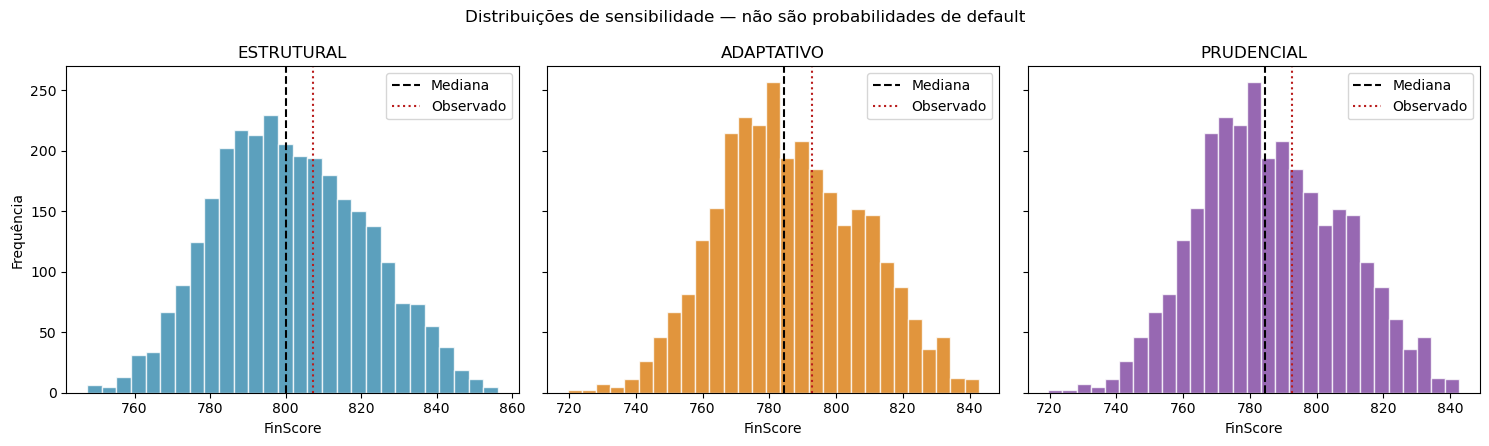

In [19]:
if MODELO_APTO:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
    methods = ["estrutural", "adaptativo", "prudencial"]
    colors = ["#2E86AB", "#D97706", "#7A3E9D"]

    for ax, method, color in zip(axes, methods, colors):
        column = f"finscore_{method}"
        ax.hist(
            df_simulacoes[column], bins="fd", color=color,
            alpha=0.78, edgecolor="white"
        )
        ax.axvline(
            df_simulacoes[column].median(), color="black",
            linestyle="--", label="Mediana"
        )
        observed_value = finscore_observado.get(column, np.nan)
        if np.isfinite(observed_value):
            ax.axvline(
                observed_value, color="#B91C1C",
                linestyle=":", label="Observado"
            )
        ax.set_title(method.upper())
        ax.set_xlabel("FinScore")
        ax.legend()

    axes[0].set_ylabel("Frequência")
    fig.suptitle("Distribuições de sensibilidade — não são probabilidades de default")
    plt.tight_layout()
    plt.show()


## 6. Evidência externa — Serasa


In [20]:
def assess_external_credit(
    finscore_prudential,
    serasa_score,
    consultation_date=None,
    severe_restriction=False,
) -> pd.DataFrame:
    if serasa_score is None or pd.isna(serasa_score):
        return pd.DataFrame([{
            "serasa_score": np.nan,
            "data_consulta": consultation_date,
            "status": "AUSENTE",
            "divergencia_pontos": np.nan,
            "nivel_divergencia": "não calculado",
            "direcao": "avaliação externa ausente",
            "restricao_grave": bool(severe_restriction),
            "score_integrado": np.nan,
        }])
    if not 0 <= float(serasa_score) <= 1000:
        raise ValueError("SERASA_SCORE deve estar entre 0 e 1.000.")

    if pd.isna(finscore_prudential):
        difference = np.nan
        level = "não calculado"
        direction = "FinScore indisponível"
    else:
        signed = float(serasa_score) - float(finscore_prudential)
        difference = abs(signed)
        if difference <= 100:
            level = "baixa"
        elif difference <= 200:
            level = "moderada"
        elif difference <= 300:
            level = "relevante"
        else:
            level = "elevada"
        direction = (
            "convergente" if difference <= 100
            else "evidência externa mais favorável" if signed > 0
            else "evidência externa mais desfavorável"
        )

    status = "ESCALONAR_RESTRICAO_GRAVE" if severe_restriction else "ANALISAR_CONJUNTAMENTE"
    return pd.DataFrame([{
        "serasa_score": float(serasa_score),
        "data_consulta": consultation_date,
        "status": status,
        "divergencia_pontos": difference,
        "nivel_divergencia": level,
        "direcao": direction,
        "restricao_grave": bool(severe_restriction),
        # Deliberadamente ausente: não há média automática.
        "score_integrado": np.nan,
    }])


df_serasa = assess_external_credit(
    finscore_observado.get("finscore_prudencial", np.nan),
    SERASA_SCORE,
    SERASA_DATA_CONSULTA,
    SERASA_RESTRICAO_GRAVE,
)
display(df_serasa)


,serasa_score,data_consulta,status,divergencia_pontos,nivel_divergencia,direcao,restricao_grave,score_integrado
0,NaN,None,AUSENTE,NaN,não calculado,avaliação externa ausente,False,NaN


## 7. Autotestes


In [21]:
def synthetic_valid_data() -> pd.DataFrame:
    data = {
        "ano": [2023, 2024, 2025],
        "p_Caixa_Equivalentes": [100, 120, 150],
        "p_Contas_Receber_Clientes": [300, 330, 360],
        "p_Estoques": [200, 210, 220],
        "p_Ativo_Circulante": [700, 760, 830],
        "p_Imobilizado_Liquido": [500, 540, 580],
        "p_Ativo_Total": [1400, 1500, 1600],
        "p_Fornecedores": [150, 160, 170],
        "p_Obrigacoes_Tributarias_CP": [40, 45, 50],
        "p_Obrigacoes_Trabalhistas_CP": [60, 65, 70],
        "p_Passivo_Circulante": [400, 420, 430],
        "p_Passivo_Nao_Circulante": [300, 280, 250],
        "p_Emprestimos_Financiamentos_CP": [100, 90, 80],
        "p_Emprestimos_Financiamentos_LP": [250, 230, 200],
        "p_Patrimonio_Liquido": [700, 800, 920],
        "r_Receita_Liquida": [2000, 2200, 2420],
        "r_CMV_CPV_CSV": [1200, 1300, 1400],
        "r_Resultado_Antes_IR_CSLL": [200, 240, 300],
        "r_Lucro_Liquido": [140, 168, 210],
        "r_Receitas_Financeiras": [10, 10, 12],
        "r_Despesa_de_Impostos": [60, 72, 90],
        "r_Despesas_Financeiras": [50, 45, 40],
    }
    return pd.DataFrame(data)


def run_self_tests() -> pd.DataFrame:
    tests = []

    def check(name, condition, detail=""):
        tests.append({
            "teste": name,
            "status": "PASSOU" if bool(condition) else "FALHOU",
            "detalhe": detail,
        })

    base = synthetic_valid_data()
    original = base.copy(deep=True)
    empty_report = pd.DataFrame(
        columns=["severidade", "tipo", "conta", "exercicios", "detalhe", "bloqueia_score"]
    )
    prepared, quality, audit, status = validate_correct_and_prepare(base, empty_report, [])

    check("21 contas primárias", len(PRIMARY) == 21)
    check("base sintética aprovada", status["apto_calculo"])
    check("base sintética sem correções", audit.empty)
    check("dados reportados imutáveis", base.equals(original))

    derived = derive(prepared)
    balance_difference = (
        prepared.p_Ativo_Total - prepared.p_Passivo_Circulante
        - prepared.p_Passivo_Nao_Circulante - prepared.p_Patrimonio_Liquido
    )
    check("identidade do balanço", np.allclose(balance_difference, 0))

    index_table = indices(derived)
    check("crescimento inicial ausente", pd.isna(index_table.iloc[0]["crescimento_receita"]))
    score_table = score_indices(index_table)
    scores, profiles = calculate_scores(score_table)
    check(
        "scores limitados a 0-1000",
        all(0 <= scores[k] <= 1000 for k in [
            "finscore_estrutural", "finscore_adaptativo", "finscore_prudencial"
        ]),
    )
    check(
        "prudencial é o menor",
        np.isclose(
            scores["finscore_prudencial"],
            min(scores["finscore_estrutural"], scores["finscore_adaptativo"]),
        ),
    )
    check(
        "pesos PCA válidos",
        all(
            np.isclose(profile.weights.sum(), 1.0)
            and (profile.weights >= 0).all()
            for profile in profiles.values()
        ),
    )

    result_a, diagnostics_a = run_sensitivity(prepared, 120, 12345)
    result_b, diagnostics_b = run_sensitivity(prepared, 120, 12345)
    score_columns = [
        "finscore_estrutural", "finscore_adaptativo", "finscore_prudencial"
    ]
    check(
        "reprodutibilidade por semente",
        np.allclose(result_a[score_columns], result_b[score_columns]),
    )
    check(
        "simulações dentro da escala",
        result_a[score_columns].ge(0).all().all()
        and result_a[score_columns].le(1000).all().all(),
    )

    corrupted = base.copy()
    corrupted.loc[2, "p_Passivo_Circulante"] = 100
    _, corrupt_quality, corrupt_audit, corrupt_status = validate_correct_and_prepare(corrupted, empty_report, [])
    check(
        "subtotal inconsistente é colocado em quarentena",
        corrupt_quality["tipo"].eq("subtotal_inferior_componentes").any()
        and corrupt_audit["acao"].eq("QUARENTENA_DETALHAMENTO").any(),
    )

    serasa_test = assess_external_credit(scores["finscore_prudencial"], 500)
    check(
        "Serasa não gera média automática",
        pd.isna(serasa_test.loc[0, "score_integrado"]),
    )

    
    known_problem = base.copy()
    known_problem.loc[0, "p_Passivo_Nao_Circulante"] = 100
    known_problem.loc[0, "p_Ativo_Total"] = (
        known_problem.loc[0, "p_Passivo_Circulante"]
        + known_problem.loc[0, "p_Patrimonio_Liquido"]
    )
    known_problem.loc[0, "p_Ativo_Circulante"] = 600
    known_problem.loc[2, "p_Passivo_Nao_Circulante"] = np.nan
    known_problem.loc[2, "p_Passivo_Circulante"] = 430
    known_problem.loc[2, "p_Obrigacoes_Tributarias_CP"] = 300
    known_problem.loc[2, "p_Obrigacoes_Trabalhistas_CP"] = 250
    corrected, known_quality, known_audit, known_status = (
        validate_correct_and_prepare(known_problem, empty_report, [])
    )
    check(
        "correção automática não altera origem",
        known_problem.loc[0, "p_Passivo_Nao_Circulante"] == 100,
    )
    check(
        "rubrica redundante corrigida apenas na análise",
        np.isclose(corrected.loc[0, "p_Passivo_Nao_Circulante"], 0),
    )
    check(
        "parcela ausente inferida e auditada",
        pd.notna(corrected.loc[2, "p_Passivo_Nao_Circulante"])
        and known_audit["acao"].eq("INFERENCIA_IDENTIDADE").any(),
    )
    check(
        "score com correção material é provisório",
        known_status["apto_calculo"] and known_status["score_provisorio"]
        and not known_status["apto_decisao"],
    )

    return pd.DataFrame(tests)



df_autotestes = run_self_tests() if EXECUTAR_AUTOTESTES else pd.DataFrame()
if EXECUTAR_AUTOTESTES:
    display(df_autotestes)
    if not df_autotestes["status"].eq("PASSOU").all():
        raise AssertionError("Há autoteste(s) com falha; revise antes de usar o modelo.")


,teste,status,detalhe
0,21 contas primárias,PASSOU,
1,base sintética aprovada,PASSOU,
2,base sintética sem correções,PASSOU,
3,dados reportados imutáveis,PASSOU,
4,identidade do balanço,PASSOU,
5,crescimento inicial ausente,PASSOU,
6,scores limitados a 0-1000,PASSOU,
7,prudencial é o menor,PASSOU,
8,pesos PCA válidos,PASSOU,
9,reprodutibilidade por semente,PASSOU,


## 8. Exportação opcional


In [22]:
from openpyxl.comments import Comment
from openpyxl.styles import Alignment, Font, PatternFill
from openpyxl.utils import get_column_letter


PARAMETROS_REGRAS = {
    "versao": VERSAO_MODELO,
    "politica_correcao": POLITICA_CORRECAO,
    "limiar_confianca_automatica": LIMIAR_CONFIANCA_AUTOMATICA,
    "limiar_materialidade": LIMIAR_MATERIALIDADE,
    "limiar_vies_alto": LIMIAR_VIES_ALTO,
    "tolerancia_balanco": BALANCE_TOLERANCE,
    "cobertura_minima_nucleo": MIN_NUCLEUS_COVERAGE,
    "participacao_pca": PCA_ADAPTIVE_SHARE,
    "pesos_nucleos": NUCLEUS_WEIGHTS,
    "pesos_temporais": TEMPORAL_WEIGHTS.tolist(),
}
HASH_REGRAS = hashlib.sha256(
    json.dumps(PARAMETROS_REGRAS, sort_keys=True).encode("utf-8")
).hexdigest()

df_configuracao = pd.DataFrame({
    "parametro": [
        "versao", "planilha", "aba", "simulacoes", "semente",
        "data_hora_processamento", "politica_correcao",
        "aplicar_correcoes_automaticas", "limiar_confianca_automatica",
        "limiar_materialidade", "limiar_vies_alto",
        "delta_min", "delta_max", "peso_EO", "peso_FP",
        "participacao_pca", "cobertura_minima_nucleo", "proxy_juros",
        "status_base", "score_provisorio", "hash_dados_reportados",
        "hash_dados_utilizados", "hash_regras",
    ],
    "valor": [
        VERSAO_MODELO, str(CAMINHO_PLANILHA), ABA_DADOS, NUM_SIMULACOES,
        SEMENTE, DATA_HORA_PROCESSAMENTO.strftime("%Y-%m-%d %H:%M:%S"),
        POLITICA_CORRECAO, APLICAR_CORRECOES_AUTOMATICAS,
        LIMIAR_CONFIANCA_AUTOMATICA, LIMIAR_MATERIALIDADE,
        LIMIAR_VIES_ALTO, DELTA_MIN, DELTA_MAX,
        NUCLEUS_WEIGHTS["EO"], NUCLEUS_WEIGHTS["FP"],
        PCA_ADAPTIVE_SHARE, MIN_NUCLEUS_COVERAGE,
        USAR_DESPESAS_FINANCEIRAS_COMO_PROXY_JUROS,
        status_qualidade["status"], status_qualidade["score_provisorio"],
        HASH_DADOS_REPORTADOS, HASH_DADOS_UTILIZADOS, HASH_REGRAS,
    ],
})

df_resumo_modelo = pd.DataFrame({
    "campo": [
        "Versão", "Status do cálculo", "Apto para decisão",
        "Natureza do score", "Correções/quarentenas aplicadas",
        "Pendências de confirmação", "Alertas de viés alto/crítico",
        "FinScore estrutural", "FinScore adaptativo", "FinScore prudencial",
        "Hash da base reportada", "Hash da base utilizada",
    ],
    "valor": [
        VERSAO_MODELO,
        status_qualidade["status"],
        "SIM" if status_qualidade["apto_decisao"] else "NÃO",
        (
            "PROVISÓRIO — NÃO USAR EM DECISÃO"
            if status_qualidade["score_provisorio"]
            else "DEFINITIVO NA POLÍTICA ATUAL"
        ),
        status_qualidade["correcoes_aplicadas"],
        status_qualidade["correcoes_pendentes_confirmacao"],
        status_qualidade.get("alertas_vies_alto_critico", 0),
        finscore_observado.get("finscore_estrutural", np.nan),
        finscore_observado.get("finscore_adaptativo", np.nan),
        finscore_observado.get("finscore_prudencial", np.nan),
        HASH_DADOS_REPORTADOS,
        HASH_DADOS_UTILIZADOS,
    ],
})


def _style_workbook(workbook):
    '''Formatação operacional: destaque visual sem esconder a trilha de auditoria.'''
    navy = "17365D"
    red = "F4CCCC"
    amber = "FCE5CD"
    green = "D9EAD3"
    blue = "D9EAF7"
    gray = "E7E6E6"

    for worksheet in workbook.worksheets:
        worksheet.freeze_panes = "A2"
        worksheet.sheet_view.showGridLines = False
        worksheet.auto_filter.ref = worksheet.dimensions
        for cell in worksheet[1]:
            cell.fill = PatternFill("solid", fgColor=navy)
            cell.font = Font(color="FFFFFF", bold=True)
            cell.alignment = Alignment(
                horizontal="center", vertical="center", wrap_text=True
            )
        worksheet.row_dimensions[1].height = 34

        for column_cells in worksheet.columns:
            letter = get_column_letter(column_cells[0].column)
            max_length = 0
            for cell in column_cells[:200]:
                if cell.value is not None:
                    max_length = max(max_length, len(str(cell.value)))
                cell.alignment = Alignment(
                    vertical="top",
                    wrap_text=cell.column in {5, 14, 15, 16, 18, 19, 20, 24, 25},
                )
            worksheet.column_dimensions[letter].width = min(
                max(max_length + 2, 11), 55
            )

        headers = {
            cell.value: cell.column for cell in worksheet[1] if cell.value is not None
        }
        for label in ["severidade", "potencial_vies", "risco_vies", "status", "status_acao"]:
            if label not in headers:
                continue
            column = headers[label]
            for row in range(2, worksheet.max_row + 1):
                cell = worksheet.cell(row, column)
                text = str(cell.value).upper()
                if "CRIT" in text or "NAO APTA" in text:
                    cell.fill = PatternFill("solid", fgColor=red)
                elif "ALTO" in text or "PROVIS" in text or "PEND" in text:
                    cell.fill = PatternFill("solid", fgColor=amber)
                elif "PASS" in text or "APTA PARA" in text or "CONTROLADO" in text:
                    cell.fill = PatternFill("solid", fgColor=green)
                elif "QUARENTENA" in text or "INFO" in text:
                    cell.fill = PatternFill("solid", fgColor=blue)

        for header, column in headers.items():
            header_text = str(header).lower()
            if any(token in header_text for token in [
                "valor_", "delta_absoluto", "score", "observado",
                "media", "mediana", "minimo", "maximo",
            ]):
                for row in range(2, worksheet.max_row + 1):
                    worksheet.cell(row, column).number_format = (
                        '#,##0.00;[Red](#,##0.00);-'
                    )
            if any(token in header_text for token in [
                "percentual", "materialidade", "confianca",
                "correlacao", "variancia", "participacao",
                "peso_", "freq_", "impacto_absoluto",
            ]):
                for row in range(2, worksheet.max_row + 1):
                    worksheet.cell(row, column).number_format = "0.00%"

        # Formatos semanticamente específicos. "Cobertura de juros" é múltiplo,
        # enquanto "cobertura do núcleo" é percentual de informação disponível.
        if worksheet.title == "score_observado":
            for header, column in headers.items():
                if str(header).startswith("cobertura_"):
                    for row in range(2, worksheet.max_row + 1):
                        worksheet.cell(row, column).number_format = "0.00%"
        elif worksheet.title == "indices_observados":
            percentage_indicators = {
                "crescimento_receita", "margem_bruta", "margem_ebit",
                "margem_liquida", "endividamento_exigivel",
                "divida_liquida_ativo", "composicao_endividamento",
            }
            multiple_indicators = {
                "giro_ativo", "liquidez_corrente", "liquidez_seca",
                "cobertura_juros",
            }
            for header, column in headers.items():
                if header in percentage_indicators:
                    for row in range(2, worksheet.max_row + 1):
                        worksheet.cell(row, column).number_format = "0.00%"
                elif header in multiple_indicators:
                    for row in range(2, worksheet.max_row + 1):
                        worksheet.cell(row, column).number_format = "0.00x"
        elif worksheet.title == "notas_observadas":
            for column in headers.values():
                for row in range(2, worksheet.max_row + 1):
                    worksheet.cell(row, column).number_format = "0.00"

        # Abas narrativas precisam de altura suficiente para evidência, regra e
        # recomendação permanecerem legíveis no primeiro acesso.
        narrative_heights = {
            "correcoes_auditoria": 72,
            "alertas_vies_material": 72,
            "qualidade_dados": 48,
        }
        if worksheet.title in narrative_heights:
            for row in range(2, worksheet.max_row + 1):
                worksheet.row_dimensions[row].height = narrative_heights[
                    worksheet.title
                ]

    if "correcoes_auditoria" in workbook.sheetnames:
        ws = workbook["correcoes_auditoria"]
        comments = {
            "valor_original": "Valor lido da planilha-fonte, nunca sobrescrito.",
            "valor_utilizado": "Valor empregado somente na cópia analítica.",
            "confianca": "Confiança da regra; não equivale a probabilidade estatística.",
            "materialidade_pct_ativo": "Magnitude da mudança dividida pelo Ativo Total do exercício.",
            "confirmado": "Deve ser verdadeiro somente após verificação documental.",
        }
        for cell in ws[1]:
            if cell.value in comments:
                cell.comment = Comment(comments[cell.value], "Fernando")

    if "resumo_modelo" in workbook.sheetnames:
        ws = workbook["resumo_modelo"]
        for row in range(2, ws.max_row + 1):
            field = str(ws.cell(row, 1).value)
            if "Status" in field or "Natureza" in field or "Apto" in field:
                ws.cell(row, 2).font = Font(bold=True)
                text = str(ws.cell(row, 2).value).upper()
                fill = red if "NÃO" in text or "NAO" in text else (
                    amber if "PROVIS" in text else green
                )
                ws.cell(row, 2).fill = PatternFill("solid", fgColor=fill)


def export_audit_workbook(path: Path):
    # Cada DataFrame possui função única e nome explícito na trilha de auditoria.
    sheets = {
        "resumo_modelo": df_resumo_modelo,
        "correcoes_auditoria": df_correcoes_auditoria,
        "alertas_vies_material": df_alertas_vies,
        "qualidade_dados": df_qualidade,
        "rastreabilidade_contas": df_rastreabilidade_contas,
        "contas_reportadas": df_contas_reportadas,
        "contas_utilizadas": df_contas_analise,
        "evidencia_serasa": df_serasa,
        "autotestes": df_autotestes,
        "configuracao": df_configuracao,
    }
    if MODELO_APTO:
        sheets.update({
            "score_observado": pd.DataFrame([finscore_observado]),
            "contas_derivadas": df_contas_derivadas,
            "indices_observados": df_indices_observados,
            "notas_observadas": df_notas_observadas,
            "diagnostico_pca": df_diagnostico_pca,
            "pesos_pca": df_pesos_pca,
            "resumo_simulacao": df_resumo,
            "simulacoes": df_simulacoes,
            "sensibilidade": df_sensibilidade,
            "amplitudes": df_amplitudes,
        })

    with pd.ExcelWriter(path, engine="openpyxl") as writer:
        for sheet_name, table in sheets.items():
            table.to_excel(writer, sheet_name=sheet_name[:31], index=False)
        _style_workbook(writer.book)


if EXPORTAR_EXCEL:
    export_audit_workbook(ARQUIVO_SAIDA)
    print(f"Resultados salvos em: {ARQUIVO_SAIDA.resolve()}")
else:
    print("Exportação Excel desativada.")


Resultados salvos em: C:\Users\ferna\Documents\dev\Finscore\FinScore\V. 2 (Pudim)\algoritmos\resultados_finscore_2.0.6_20260723_1349.xlsx


## 9. Interpretação e limites

### Ordem obrigatória de leitura

1. `resumo_modelo`;
2. `correcoes_auditoria`;
3. `alertas_vies_material`;
4. `qualidade_dados`;
5. somente depois, os scores e a simulação.

### Significado do resultado provisório

O cálculo provisório responde:

> Qual seria o diagnóstico do FinScore se as correções analíticas de alta
> confiança forem posteriormente confirmadas?

Ele não autoriza crédito, limite ou precificação. A confirmação deve registrar
documento-fonte, responsável e data. A planilha original continuará preservada.

### Limitações

- PCA com três exercícios permanece exploratório e limitado a dois componentes.
- O peso adaptativo continua encolhido para 30%.
- Monte Carlo mede sensibilidade parametrizada, não PD.
- Curvas de nota limitam o efeito de valores extremos, mas não validam sua origem.
- Ausência de CMV e dívida de longo prazo reduz cobertura informacional.
- O Serasa permanece evidência externa separada.
